In [1]:
# ============================================================
# 0. Environment check + dependencies
# ============================================================
import subprocess, sys

print("Checking GPU...")
subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"])

# albumentations is pinned loosely; the code below is written to work with BOTH the
# 1.x and the 2.x augmentation APIs, so whichever version Kaggle ships is fine.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations", "kaggle"],
               check=False)
print("Dependencies ready.")


Checking GPU...
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
Dependencies ready.


# Task 3 (Part 1 of 2) — Improvement, Final Model, Ablation, 5-Fold CV & Significance

**Group03 | Dataset: PRBD (Processed Rice Bangladesh) | Track 3 — CNN + Attention**

This notebook is the direct continuation of `Group03_PRBD_task2_proposed_model.ipynb`
(ResNet50 + CBAM, test Macro-F1 = 0.9548, which sat **below** the plain ResNet50 baseline
at 0.9625). Task 3 asks us to *improve* that model, prove the improvement statistically,
and explain it.

### What this notebook produces (Task 3 deliverables, part 1)

| Task 3 requirement | Where it is done |
|---|---|
| **Improve** (fine-tuning depth, dropout, attention module, LR schedule, optimizer, augmentation, early stopping, input size) | Stage 1 |
| **Final model** trained + evaluated on the held-out test set | Stage 2 |
| **Ablation:** CNN without attention; channel vs. spatial vs. CBAM | Stage 3A |
| **Ablation:** conv-block counts, filters, kernel size, batch-norm on/off, dropout on/off, augmentation on/off | Stage 3A + 3B |
| **5-fold CV (mean ± std)** + **significance test** vs. the best baseline | Stage 4 |
| **Final performance:** best baseline vs. first model vs. final model vs. related work | Stage 5 |
| **Explainability (Grad-CAM + LIME)** | **Notebook 2** — `Group03_PRBD_task3_explainability.ipynb` |

### Leakage-free protocol 
* The **same class-stratified 70/10/20 split** as Task 2 is used (loaded if present, otherwise
  regenerated with the identical seed and method, which reproduces it exactly).
* **Every model-selection decision in Stage 1 is made on the validation set only.** The test set is
  touched exactly once per final/reported model, after the configuration is frozen.
* **5-fold CV runs over the train+val portion only** — the 20% test split is never part of any fold.
* Both models in the significance test see **identical folds** so the test is properly paired.


In [2]:
# ============================================================
# 1. Dataset path (Kaggle) -- auto-detected, no hardcoded username/slug
# ============================================================
import os, glob

CANDIDATE_DIRS = [
    "/kaggle/input/datasets/rejaul5/rice-varieties-microscopic/Original_Images",
    "/kaggle/input/prbd-processed-rice-bangladesh-dataset/Original_Images",
    "/kaggle/input/prbd/Original_Images",
    "/kaggle/input/prbd-dataset/Original_Images",
]

EXPECTED_DIR = "/kaggle/input/datasets/rejaul5/rice-varieties-microscopic/Original_Images"
for c in CANDIDATE_DIRS:
    if os.path.isdir(c):
        EXPECTED_DIR = c
        break

if EXPECTED_DIR is None:
    # last resort: walk every attached Kaggle input dataset looking for the
    # Original_Images folder, so this cell survives the dataset being attached
    # under any username/slug.
    for base, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(base) == "Original_Images":
            EXPECTED_DIR = base
            break

assert EXPECTED_DIR is not None, (
    "Could not auto-locate Original_Images under /kaggle/input. "
    "Attach the PRBD dataset to this notebook (Add Input), or set EXPECTED_DIR manually."
)
print("Dataset root:", EXPECTED_DIR)
print("Classes on disk:", len(os.listdir(EXPECTED_DIR)))


Dataset root: /kaggle/input/datasets/rejaul5/rice-varieties-microscopic/Original_Images
Classes on disk: 10


In [3]:
# ============================================================
# 2. Imports, seeds, global configuration
# ============================================================
import os, glob, random, time, json, copy, math, warnings
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
cv2.setNumThreads(0)                      # avoid OpenCV threads fighting the DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
from scipy import stats

import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision
from torchvision import models

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------- paths (identical layout to Task 2) ----------------
BASE_PATH   = EXPECTED_DIR
WORK_DIR = "/kaggle/working/work"
SPLIT_DIR   = os.path.join(WORK_DIR, "splits")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
MODELS_DIR  = os.path.join(WORK_DIR, "models")
FIG_DIR     = os.path.join(WORK_DIR, "figures")
for d in [SPLIT_DIR, RESULTS_DIR, MODELS_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ---------------- experiment budget ----------------
FAST_MODE = False        # True = 2-epoch smoke test on a data subset (~15 min). Set False for the real run.
RESUME    = True         # skip experiments already recorded in the run registry

RUN_STAGE1_SEARCH   = True
RUN_STAGE2_FINAL    = True
RUN_STAGE3_ABLATION = True
RUN_STAGE4_CV       = True

IMG_SIZE       = 224     # default input size (Stage 1 also tries 256)
BATCH_SIZE     = 32
NUM_WORKERS    = 2
USE_AMP        = torch.cuda.is_available()   # mixed precision -> ~1.7x faster on a T4

SEARCH_EPOCHS   = 10 if not FAST_MODE else 2
ABLATION_EPOCHS = 10 if not FAST_MODE else 2
CV_EPOCHS       = 12 if not FAST_MODE else 2
FINAL_EPOCHS    = 30 if not FAST_MODE else 2
PATIENCE        = 6
SEARCH_PATIENCE = 4
N_FOLDS         = 5 if not FAST_MODE else 2

CLASSES = sorted(os.listdir(BASE_PATH))
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
print(f"\n{NUM_CLASSES} classes:", CLASSES)
print("FAST_MODE =", FAST_MODE, "| AMP =", USE_AMP)


Device: cuda
GPU: Tesla T4

10 classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
FAST_MODE = False | AMP = True


In [4]:
# ============================================================
# 3. The SAME split as Task 2 (loaded if available, else reproduced deterministically)
# ============================================================
records = []
for cls in CLASSES:
    cls_path = os.path.join(BASE_PATH, cls)
    files_ = sorted(f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    for f in files_:
        records.append({"class": cls, "label": CLASS_TO_IDX[cls], "filename": f,
                        "path": os.path.join(cls_path, f)})
df = pd.DataFrame(records)
print("Total images:", len(df))
print(df["class"].value_counts().sort_index().to_string())

SPLIT_CSV = os.path.join(SPLIT_DIR, "group03_prbd_task2_split.csv")

def _find_existing_split():
    """Look for the Task 2 split CSV in this session, in an attached Kaggle dataset/input,
    or on Drive."""
    for cand in [SPLIT_CSV,
                 "/kaggle/working/splits_gnn_draft.csv",
                 "/content/splits/group03_prbd_task2_split.csv",
                 "/content/work/splits/group03_prbd_task2_split.csv",
                 "/content/drive/MyDrive/group03_prbd_task2_split.csv"]:
        if os.path.exists(cand):
            return cand
    hits = (glob.glob("/kaggle/input/**/group03_prbd_task2_split.csv", recursive=True)
            + glob.glob("/kaggle/working/**/group03_prbd_task2_split.csv", recursive=True)
            + glob.glob("/content/**/group03_prbd_task2_split.csv", recursive=True))
    return hits[0] if hits else None

found = _find_existing_split()
if found:
    split_df = pd.read_csv(found)
    print("\nLoaded Task 2 split from:", found)
else:
    # Identical seed + identical stratified method + identical (sorted) file ordering
    # => byte-for-byte the same partition as Task 2.
    train_df_, temp_df = train_test_split(df, test_size=0.30, stratify=df["class"], random_state=SEED)
    val_df_, test_df_  = train_test_split(temp_df, test_size=(2/3), stratify=temp_df["class"], random_state=SEED)
    train_df_ = train_df_.copy(); train_df_["split"] = "train"
    val_df_   = val_df_.copy();   val_df_["split"]   = "val"
    test_df_  = test_df_.copy();  test_df_["split"]  = "test"
    split_df = pd.concat([train_df_, val_df_, test_df_], ignore_index=True)
    split_df.to_csv(SPLIT_CSV, index=False)
    print("\nNo Task 2 split file found — regenerated deterministically (same seed/method) at", SPLIT_CSV)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

if FAST_MODE:   # small stratified subset just to prove the pipeline runs end-to-end
    train_df = train_df.groupby("class", group_keys=False).head(24).reset_index(drop=True)
    val_df   = val_df.groupby("class",   group_keys=False).head(8).reset_index(drop=True)
    test_df  = test_df.groupby("class",  group_keys=False).head(12).reset_index(drop=True)
    print("FAST_MODE subset active.")

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# --- leakage assertions (Pillar A) ---
assert set(train_df["path"]) & set(val_df["path"])  == set(), "train/val overlap!"
assert set(train_df["path"]) & set(test_df["path"]) == set(), "train/test overlap!"
assert set(val_df["path"])   & set(test_df["path"]) == set(), "val/test overlap!"
print("Leakage check passed — train / val / test are disjoint.")

# train+val pool used for 5-fold CV (test is NEVER part of any fold)
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
print("CV pool (train+val):", len(trainval_df), "| held-out test:", len(test_df))


Total images: 2000
class
Aush             200
BR-28            200
BR-29            200
Beroi            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200

No Task 2 split file found — regenerated deterministically (same seed/method) at /kaggle/working/work/splits/group03_prbd_task2_split.csv
train=1400  val=200  test=400
Leakage check passed — train / val / test are disjoint.
CV pool (train+val): 1600 | held-out test: 400


In [5]:
# ============================================================
# 4. Task 2 reference numbers (best baseline + first model)
# ============================================================
# These are the results your Task 2 notebooks produced. The loader below tries to read the
# real JSON files first; if this is a fresh Kaggle session it falls back to the values recorded
# in the Task 2 notebook so the comparison table always renders.

TASK2_FALLBACK = [
    {"model": "Simple CNN (baseline)",        "f1_macro": 0.8900, "source": "task2_baselines"},
    {"model": "EfficientNet-B0 (baseline)",   "f1_macro": 0.9524, "source": "task2_baselines"},
    {"model": "MobileNetV2 (baseline)",       "f1_macro": 0.9622, "source": "task2_baselines"},
    {"model": "ResNet50 (baseline, BEST)",    "f1_macro": 0.9625, "source": "task2_baselines"},
    {"model": "ResNet50+CBAM (first model)",  "f1_macro": 0.9548, "source": "task2_proposed"},
]

def _load_task2_results():
    for cand in glob.glob("/content/**/group03_prbd_task2_baseline_results.json", recursive=True):
        try:
            with open(cand) as f:
                data = json.load(f)
            print("Loaded real Task 2 baseline results from:", cand)
            return data, True
        except Exception:
            pass
    print("Task 2 JSON not found in this session — using the values recorded in the Task 2 notebook.")
    return TASK2_FALLBACK, False

task2_results, task2_is_real = _load_task2_results()
task2_df = pd.DataFrame(task2_results)

BEST_BASELINE_NAME = "ResNet50 (baseline)"
BEST_BASELINE_F1   = float(max(r["f1_macro"] for r in task2_results
                               if "baseline" in r["model"].lower()))
FIRST_MODEL_F1     = 0.9548   # Task 2 proposed ResNet50+CBAM

print(f"\nBest Task 2 baseline  : {BEST_BASELINE_NAME}  Macro-F1 = {BEST_BASELINE_F1:.4f}")
print(f"Task 2 first model    : ResNet50+CBAM         Macro-F1 = {FIRST_MODEL_F1:.4f}")
print(f"Gap to close in Task 3: {FIRST_MODEL_F1 - BEST_BASELINE_F1:+.4f}")
task2_df


Task 2 JSON not found in this session — using the values recorded in the Task 2 notebook.

Best Task 2 baseline  : ResNet50 (baseline)  Macro-F1 = 0.9625
Task 2 first model    : ResNet50+CBAM         Macro-F1 = 0.9548
Gap to close in Task 3: -0.0077


,model,f1_macro,source
0,Simple CNN (baseline),0.8900,task2_baselines
1,EfficientNet-B0 (baseline),0.9524,task2_baselines
2,MobileNetV2 (baseline),0.9622,task2_baselines
3,"ResNet50 (baseline, BEST)",0.9625,task2_baselines
4,ResNet50+CBAM (first model),0.9548,task2_proposed


## 5. Data pipeline — version-safe augmentation with four strength levels

Augmentation strength is one of the things Task 3 asks us to vary, so it is a first-class
configuration knob here (`none` / `light` / `medium` / `strong`). `medium` is **exactly** the Task 2
recipe, so every Task 2 result stays reproducible inside this notebook.

The builders below construct the same transforms across **both** the Albumentations 1.x and 2.x
API's (the `CoarseDropout` and affine argument names changed between them), so the notebook does not
break when Kaggle updates the library.


In [6]:
# ============================================================
# 5. Transforms, dataset, loaders
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def _coarse_dropout(p=0.3, holes=4, h=20, w=20):
    """CoarseDropout across albumentations 1.x and 2.x argument names."""
    try:
        return A.CoarseDropout(num_holes_range=(1, holes),
                               hole_height_range=(8, h),
                               hole_width_range=(8, w), p=p)
    except TypeError:
        return A.CoarseDropout(max_holes=holes, max_height=h, max_width=w, p=p)

def _affine(p=0.5):
    try:
        return A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.06),
                        rotate=(-25, 25), p=p)
    except TypeError:
        return A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=25, p=p)

def build_transforms(img_size=IMG_SIZE, strength="medium"):
    """strength in {none, light, medium, strong}. 'medium' == the Task 2 recipe."""
    norm = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    if strength == "none":
        aug = []
    elif strength == "light":
        aug = [A.HorizontalFlip(p=0.5),
               A.Rotate(limit=10, p=0.3, border_mode=cv2.BORDER_REFLECT)]
    elif strength == "medium":
        aug = [A.HorizontalFlip(p=0.5),
               A.VerticalFlip(p=0.2),
               A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT),
               A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
               A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
               _coarse_dropout(p=0.3)]
    elif strength == "strong":
        aug = [A.HorizontalFlip(p=0.5),
               A.VerticalFlip(p=0.5),
               _affine(p=0.6),
               A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
               A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=15, p=0.4),
               A.GaussNoise(p=0.2),
               _coarse_dropout(p=0.4, holes=8, h=28, w=28)]
    else:
        raise ValueError(f"unknown augmentation strength: {strength}")
    train_tf = A.Compose([A.Resize(img_size, img_size)] + aug + norm)
    eval_tf  = A.Compose([A.Resize(img_size, img_size)] + norm)
    return train_tf, eval_tf


class RiceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        return img, int(row["label"])


def make_loaders(tr_df, va_df, te_df=None, img_size=IMG_SIZE, strength="medium", batch_size=BATCH_SIZE):
    train_tf, eval_tf = build_transforms(img_size, strength)
    g = torch.Generator(); g.manual_seed(SEED)
    tl = DataLoader(RiceDataset(tr_df, train_tf), batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False, generator=g)
    vl = DataLoader(RiceDataset(va_df, eval_tf), batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    el = None
    if te_df is not None:
        el = DataLoader(RiceDataset(te_df, eval_tf), batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    return tl, vl, el

# sanity check
_tl, _vl, _el = make_loaders(train_df, val_df, test_df)
_xb, _yb = next(iter(_tl))
print("Batch tensor:", _xb.shape, _xb.dtype, "| labels:", _yb.shape)
print("Batches -> train:", len(_tl), " val:", len(_vl), " test:", len(_el))


Batch tensor: torch.Size([32, 3, 224, 224]) torch.float32 | labels: torch.Size([32])
Batches -> train: 44  val: 7  test: 13


## 6. Attention modules — channel, spatial, and full CBAM

Task 3's ablation requires comparing **channel-only vs. spatial-only vs. full CBAM**, so the three
are defined as independent, swappable modules rather than one fused block. `ChannelAttention` and
`SpatialAttention` are byte-identical to Task 2; `CBAM` chains them in the standard
Woo et al. (ECCV 2018) order (channel first, then spatial).


In [7]:
# ============================================================
# 6. Attention modules
# ============================================================
class ChannelAttention(nn.Module):
    """Which feature CHANNELS matter: avg+max pool -> shared MLP -> sigmoid gate."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(in_channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_channels, 1, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        attn = self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))
        return x * attn


class SpatialAttention(nn.Module):
    """Which LOCATIONS matter: channel-wise avg+max -> kxk conv -> sigmoid gate."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn


class CBAM(nn.Module):
    """Channel attention then spatial attention (Woo et al., ECCV 2018)."""
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)
    def forward(self, x):
        return self.spatial_attn(self.channel_attn(x))


def make_attention(kind, channels, reduction=16, spatial_kernel=7):
    """Factory used by the ablation: 'none' | 'channel' | 'spatial' | 'cbam'."""
    if kind == "none":    return nn.Identity()
    if kind == "channel": return ChannelAttention(channels, reduction)
    if kind == "spatial": return SpatialAttention(spatial_kernel)
    if kind == "cbam":    return CBAM(channels, reduction, spatial_kernel)
    raise ValueError(f"unknown attention type: {kind}")

print("Attention modules defined: none / channel / spatial / cbam")


Attention modules defined: none / channel / spatial / cbam


## 7. Two configurable model families

**`ResNet50Attn`** — the improvement/ablation vehicle. Every knob Task 3 asks us to vary is a
constructor argument:

| Argument | Values | Task 3 requirement it covers |
|---|---|---|
| `attention` | `none` / `channel` / `spatial` / `cbam` | attention-module ablation |
| `placement` | `all` (after every stage) / `last` (after `layer4` only) | attention-module ablation |
| `unfreeze` | `layer4` / `layer3_4` / `layer2_3_4` | fine-tuning depth |
| `dropout` | float | dropout on/off |
| `reduction`, `spatial_kernel` | int | attention-module hyper-parameters |

Setting `attention="none"` with `unfreeze="layer4"` reproduces the **plain ResNet50 baseline** — this
is what "CNN without attention" means in the ablation, and it is the model the significance test
compares against.

**`SmallCNN`** — a from-scratch CNN whose *architecture itself* is configurable
(`n_blocks`, `base_filters`, `kernel_size`, `use_bn`, `dropout`, `attention`). Conv-layer count,
filter count, kernel size and batch-norm cannot be meaningfully ablated on a fixed pretrained
ResNet50, so those four requirements are answered on this controlled family instead — which is also
where the Task 2 result "CBAM improved a from-scratch CNN by +0.0096 Macro-F1" came from.


In [8]:
# ============================================================
# 7. Model definitions
# ============================================================
class ResNet50Attn(nn.Module):
    """ImageNet-pretrained ResNet50 with a configurable attention module after each stage."""
    def __init__(self, num_classes=NUM_CLASSES, attention="cbam", placement="all",
                 dropout=0.3, unfreeze="layer3_4", reduction=16, spatial_kernel=7,
                 pretrained=True):
        super().__init__()
        self.cfg_attention = attention
        self.cfg_placement = placement
        self.cfg_unfreeze  = unfreeze

        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = models.resnet50(weights=weights)

        self.stem   = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1      # 256 ch
        self.layer2 = base.layer2      # 512 ch
        self.layer3 = base.layer3      # 1024 ch
        self.layer4 = base.layer4      # 2048 ch

        early = attention if placement == "all" else "none"
        self.attn1 = make_attention(early,     256,  reduction, spatial_kernel)
        self.attn2 = make_attention(early,     512,  reduction, spatial_kernel)
        self.attn3 = make_attention(early,     1024, reduction, spatial_kernel)
        self.attn4 = make_attention(attention, 2048, reduction, spatial_kernel)

        self.avgpool = base.avgpool
        head = [nn.Dropout(dropout)] if dropout > 0 else []
        head.append(nn.Linear(2048, num_classes))
        self.classifier = nn.Sequential(*head)

        # ---- fine-tuning budget ----
        trainable = {"layer4":     [self.layer4],
                     "layer3_4":   [self.layer3, self.layer4],
                     "layer2_3_4": [self.layer2, self.layer3, self.layer4]}[unfreeze]
        for p in self.parameters():
            p.requires_grad = False
        for mod in trainable:
            for p in mod.parameters():
                p.requires_grad = True
        for mod in [self.attn1, self.attn2, self.attn3, self.attn4, self.classifier]:
            for p in mod.parameters():
                p.requires_grad = True

    def param_groups_for_optimizer(self, backbone_lr, head_lr):
        """Pretrained weights get a small LR; freshly initialised attention/head get a larger one."""
        backbone, new = [], []
        for mod in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            backbone += [p for p in mod.parameters() if p.requires_grad]
        for mod in [self.attn1, self.attn2, self.attn3, self.attn4, self.classifier]:
            new += [p for p in mod.parameters() if p.requires_grad]
        groups = []
        if backbone: groups.append({"params": backbone, "lr": backbone_lr})
        if new:      groups.append({"params": new,      "lr": head_lr})
        return groups

    def forward(self, x, return_attention_maps=False):
        maps = {}
        x = self.stem(x)
        x = self.attn1(self.layer1(x)); maps["stage1"] = x
        x = self.attn2(self.layer2(x)); maps["stage2"] = x
        x = self.attn3(self.layer3(x)); maps["stage3"] = x
        x = self.attn4(self.layer4(x)); maps["stage4"] = x
        f = torch.flatten(self.avgpool(x), 1)
        out = self.classifier(f)
        return (out, maps) if return_attention_maps else out


class SmallCNN(nn.Module):
    """From-scratch CNN with configurable depth / width / kernel / batch-norm / attention."""
    def __init__(self, num_classes=NUM_CLASSES, n_blocks=4, base_filters=32,
                 kernel_size=3, use_bn=True, dropout=0.3, attention="none",
                 reduction=16, spatial_kernel=7):
        super().__init__()
        pad = kernel_size // 2
        blocks, in_ch = [], 3
        for b in range(n_blocks):
            out_ch = base_filters * (2 ** b)
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size, padding=pad, bias=not use_bn)]
            if use_bn: layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Conv2d(out_ch, out_ch, kernel_size, padding=pad, bias=not use_bn))
            if use_bn: layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.MaxPool2d(2))
            if attention != "none":
                layers.append(make_attention(attention, out_ch, reduction, spatial_kernel))
            blocks.append(nn.Sequential(*layers))
            in_ch = out_ch
        self.blocks = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        head = [nn.Dropout(dropout)] if dropout > 0 else []
        head.append(nn.Linear(in_ch, num_classes))
        self.classifier = nn.Sequential(*head)

    def param_groups_for_optimizer(self, backbone_lr, head_lr):
        return [{"params": [p for p in self.parameters() if p.requires_grad], "lr": head_lr}]

    def forward(self, x, return_attention_maps=False):
        maps = {}
        for i, blk in enumerate(self.blocks):
            x = blk(x); maps[f"block{i+1}"] = x
        out = self.classifier(torch.flatten(self.pool(x), 1))
        return (out, maps) if return_attention_maps else out


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_model(cfg):
    """Instantiate a model from a config dict (used everywhere below)."""
    set_seed(SEED)   # identical initialisation for every experiment -> fair comparison
    if cfg.get("family", "resnet50") == "smallcnn":
        m = SmallCNN(n_blocks=cfg.get("n_blocks", 4), base_filters=cfg.get("base_filters", 32),
                     kernel_size=cfg.get("kernel_size", 3), use_bn=cfg.get("use_bn", True),
                     dropout=cfg.get("dropout", 0.3), attention=cfg.get("attention", "none"),
                     reduction=cfg.get("reduction", 16),
                     spatial_kernel=cfg.get("spatial_kernel", 7))
    else:
        m = ResNet50Attn(attention=cfg.get("attention", "cbam"), placement=cfg.get("placement", "all"),
                         dropout=cfg.get("dropout", 0.3), unfreeze=cfg.get("unfreeze", "layer3_4"),
                         reduction=cfg.get("reduction", 16),
                         spatial_kernel=cfg.get("spatial_kernel", 7))
    return m

_m = build_model({"attention": "cbam"})
print("ResNet50Attn (cbam, layer3_4) trainable params:", f"{count_params(_m):,}")
_m2 = build_model({"family": "smallcnn", "n_blocks": 4})
print("SmallCNN (4 blocks)          trainable params:", f"{count_params(_m2):,}")
del _m, _m2


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


ResNet50Attn (cbam, layer3_4) trainable params: 22,780,306
SmallCNN (4 blocks)          trainable params: 1,175,786


## 8. Training / evaluation engine

One engine drives every experiment in this notebook so that all runs are directly comparable.
Configurable per Task 3's "improve" list: **optimizer** (Adam / AdamW / SGD-momentum),
**LR schedule** (ReduceLROnPlateau / cosine annealing / none), **label smoothing**,
**early stopping patience**, differential learning rates, and mixed precision for speed.

Every finished run is appended to `results/task3_run_registry.json`. On a re-run, completed
experiments are loaded from there instead of being retrained — so a Kaggle session interruption
costs you only the run that was in flight.


In [9]:
# ============================================================
# 8. Training engine, evaluation, plots, resumable run registry
# ============================================================
def _make_scaler(enabled):
    try:    return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception: return torch.cuda.amp.GradScaler(enabled=enabled)

def _autocast(enabled):
    if not enabled: return nullcontext()
    try:    return torch.amp.autocast("cuda")
    except Exception: return torch.cuda.amp.autocast()

def build_optimizer(model, cfg):
    groups = model.param_groups_for_optimizer(cfg.get("backbone_lr", 5e-5), cfg.get("head_lr", 5e-4))
    wd   = cfg.get("weight_decay", 1e-4)
    name = cfg.get("optimizer", "adam").lower()
    if name == "adam":  return torch.optim.Adam(groups, weight_decay=wd)
    if name == "adamw": return torch.optim.AdamW(groups, weight_decay=max(wd, 1e-2))
    if name == "sgd":   return torch.optim.SGD(groups, momentum=0.9, weight_decay=wd, nesterov=True)
    raise ValueError(f"unknown optimizer: {name}")

def build_scheduler(optimizer, cfg, epochs):
    name = cfg.get("scheduler", "plateau").lower()
    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2), True
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs), False
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs // 3, 1), gamma=0.3), False
    if name == "none":
        return None, False
    raise ValueError(f"unknown scheduler: {name}")


def train_model(model, run_name, train_loader, val_loader, cfg, epochs=None,
                patience=PATIENCE, verbose=True, save_ckpt=True):
    """Train with early stopping on val loss. Returns (model, history, seconds, best_val_loss)."""
    epochs = epochs or cfg.get("epochs", FINAL_EPOCHS)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.get("label_smoothing", 0.0))
    optimizer = build_optimizer(model, cfg)
    scheduler, step_on_val = build_scheduler(optimizer, cfg, epochs)
    scaler = _make_scaler(USE_AMP)

    best_val_loss, best_state, no_improve = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with _autocast(USE_AMP):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            run_loss += loss.item() * imgs.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
                with _autocast(USE_AMP):
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (outputs.argmax(1) == labels).sum().item()
                v_total   += labels.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        if scheduler is not None:
            scheduler.step(val_loss) if step_on_val else scheduler.step()

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        if verbose:
            print(f"[{run_name}] ep {epoch+1}/{epochs} | train {train_loss:.4f}/{train_acc:.4f} "
                  f"| val {val_loss:.4f}/{val_acc:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss, no_improve = val_loss, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose: print(f"[{run_name}] early stop at epoch {epoch+1}")
                break

    secs = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
        if save_ckpt:
            torch.save(best_state, os.path.join(MODELS_DIR, f"{run_name}_best.pth"))
    return model, history, secs, best_val_loss


@torch.no_grad()
def evaluate_model(model, model_name, loader, class_names=CLASSES, verbose=True):
    """Full metric set — identical definitions to Task 2 so numbers are comparable."""
    model.eval().to(DEVICE)
    all_labels, all_preds, all_probs = [], [], []
    t0 = time.time()
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with _autocast(USE_AMP):
            outputs = model(imgs)
        probs = F.softmax(outputs.float(), dim=1).cpu().numpy()
        all_labels.extend(labels.numpy()); all_preds.extend(probs.argmax(1)); all_probs.extend(probs)
    per_img_ms = (time.time() - t0) / max(len(loader.dataset), 1) * 1000

    y_true = np.array(all_labels); y_pred = np.array(all_preds); y_prob = np.array(all_probs)
    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    report = classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                                   target_names=class_names, zero_division=0)
    y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    aucs = []
    for i in range(len(class_names)):
        if y_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i]); aucs.append(auc(fpr, tpr))
    roc_auc_macro = float(np.mean(aucs)) if aucs else float("nan")

    metrics = {"model": model_name, "accuracy": float(acc),
               "precision_macro": float(p_m), "recall_macro": float(r_m), "f1_macro": float(f1_m),
               "precision_weighted": float(p_w), "recall_weighted": float(r_w),
               "f1_weighted": float(f1_w), "roc_auc_macro": roc_auc_macro,
               "inference_ms_per_image": float(per_img_ms),
               "n_params": int(count_params(model))}
    if verbose:
        print(f"\n===== {model_name} =====")
        print(report)
        print(f"Accuracy={acc:.4f} | Macro-F1={f1_m:.4f} | Weighted-F1={f1_w:.4f} | ROC-AUC={roc_auc_macro:.4f}")
    return metrics, y_true, y_pred, y_prob, cm, report


# ---------------- plots ----------------
def plot_history(history, title, save=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="train"); axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

def plot_confusion_matrix(cm, class_names, title, save=None):
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.xticks(rotation=75); plt.yticks(rotation=0); plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

def plot_roc_pr_curves(y_true, y_prob, class_names, title_prefix, save=None):
    y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for i, c in enumerate(class_names):
        if y_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        axes[0].plot(fpr, tpr, lw=1, label=f"{c} (AUC={auc(fpr, tpr):.2f})")
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
        axes[1].plot(rec, prec, lw=1, label=c)
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"{title_prefix} — ROC (one-vs-rest)"); axes[0].legend(fontsize=7, loc="lower right")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} — PR (one-vs-rest)"); axes[1].legend(fontsize=7, loc="lower left")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


# ---------------- resumable run registry ----------------
REGISTRY_PATH = os.path.join(RESULTS_DIR, "task3_run_registry.json")

def load_registry():
    if os.path.exists(REGISTRY_PATH):
        with open(REGISTRY_PATH) as f:
            return json.load(f)
    return {}

def registry_save(key, value):
    reg = load_registry(); reg[key] = value
    with open(REGISTRY_PATH, "w") as f:
        json.dump(reg, f, indent=2, default=float)

def registry_get(key):
    return load_registry().get(key) if RESUME else None


def run_experiment(run_name, cfg, tr_df, va_df, eval_df=None, epochs=None, patience=SEARCH_PATIENCE,
                   verbose=False, save_ckpt=False, tag=""):
    """Train one configuration and evaluate it. Cached in the registry so re-runs are instant."""
    cached = registry_get(run_name)
    if cached is not None:
        print(f"[cached] {run_name}: val_f1={cached.get('val_f1_macro', float('nan')):.4f}"
              + (f" test_f1={cached['test_f1_macro']:.4f}" if cached.get("test_f1_macro") else ""))
        return cached

    print(f"\n>>> RUN {run_name}  {tag}")
    print("    cfg:", {k: v for k, v in cfg.items() if k != "family"} , "| family:", cfg.get("family", "resnet50"))
    img_size = cfg.get("img_size", IMG_SIZE)
    strength = cfg.get("augmentation", "medium")
    bs = cfg.get("batch_size", BATCH_SIZE)
    tl, vl, el = make_loaders(tr_df, va_df, eval_df, img_size=img_size, strength=strength, batch_size=bs)

    model = build_model(cfg)
    model, hist, secs, best_val_loss = train_model(model, run_name, tl, vl, cfg,
                                                   epochs=epochs, patience=patience,
                                                   verbose=verbose, save_ckpt=save_ckpt)
    val_metrics, *_ = evaluate_model(model, f"{run_name} [val]", vl, verbose=False)
    result = {"run": run_name, "config": cfg, "epochs_run": len(hist["train_loss"]),
              "train_seconds": secs, "best_val_loss": best_val_loss,
              "val_f1_macro": val_metrics["f1_macro"], "val_accuracy": val_metrics["accuracy"],
              "n_params": val_metrics["n_params"], "history": hist}

    if el is not None:
        test_metrics, y_true, y_pred, y_prob, cm, _ = evaluate_model(model, run_name, el, verbose=False)
        result.update({"test_f1_macro": test_metrics["f1_macro"],
                       "test_accuracy": test_metrics["accuracy"],
                       "test_metrics": test_metrics})
        np.savez_compressed(os.path.join(RESULTS_DIR, f"{run_name}_test_preds.npz"),
                            y_true=y_true, y_pred=y_pred, y_prob=y_prob)

    msg = f"    -> val Macro-F1 = {result['val_f1_macro']:.4f}"
    if "test_f1_macro" in result: msg += f" | test Macro-F1 = {result['test_f1_macro']:.4f}"
    print(msg + f" | {secs/60:.1f} min | {result['epochs_run']} epochs")

    registry_save(run_name, result)
    del model
    torch.cuda.empty_cache()
    return result

print("Training engine ready. Registry:", REGISTRY_PATH)


Training engine ready. Registry: /kaggle/working/work/results/task3_run_registry.json


## Stage 1 — Improvement search (selection on the VALIDATION set only)

The Task 2 model (`BASE_CFG` below) is the starting point. Each candidate changes **exactly one
thing** relative to it, so the effect of every knob is attributable. This covers the Task 3
"improve" list: fine-tuning depth, dropout, attention module/placement, LR schedule, optimizer,
augmentation, label smoothing, and input size.

**Nothing here looks at the test set.** The winner is chosen by validation Macro-F1, then frozen.
That is what keeps the final test number an honest estimate (Pillar A, §8).


In [10]:
# ============================================================
# Stage 1 — one-factor-at-a-time improvement search (validation-selected)
# ============================================================
BASE_CFG = {   # exactly the Task 2 proposed model
    "family": "resnet50", "attention": "cbam", "placement": "all", "unfreeze": "layer3_4",
    "dropout": 0.3, "reduction": 16, "spatial_kernel": 7, "optimizer": "adam",
    "scheduler": "plateau", "backbone_lr": 5e-5, "head_lr": 5e-4, "weight_decay": 1e-4,
    "label_smoothing": 0.0, "augmentation": "medium", "img_size": 224, "batch_size": 32,
}

def variant(name, **changes):
    cfg = dict(BASE_CFG); cfg.update(changes)
    return name, cfg, ", ".join(f"{k}={v}" for k, v in changes.items())

SEARCH_VARIANTS = [
    ("s1_base_task2_model", dict(BASE_CFG), "Task 2 model (reference)"),
    variant("s1_finetune_layer4",     unfreeze="layer4"),
    variant("s1_finetune_layer2_3_4", unfreeze="layer2_3_4"),
    variant("s1_dropout_0.5",         dropout=0.5),
    variant("s1_dropout_0.0",         dropout=0.0),
    variant("s1_attn_last_only",      placement="last"),
    variant("s1_optimizer_adamw_cosine", optimizer="adamw", scheduler="cosine"),
    variant("s1_higher_backbone_lr",  backbone_lr=1e-4),
    variant("s1_label_smoothing_0.1", label_smoothing=0.1),
    variant("s1_augmentation_strong", augmentation="strong"),
    variant("s1_augmentation_light",  augmentation="light"),
    variant("s1_input_size_256",      img_size=256, batch_size=24),
]

search_results = []
if RUN_STAGE1_SEARCH:
    t_stage = time.time()
    for i, (name, cfg, desc) in enumerate(SEARCH_VARIANTS, 1):
        r = run_experiment(name, cfg, train_df, val_df, eval_df=None,
                           epochs=SEARCH_EPOCHS, patience=SEARCH_PATIENCE,
                           tag=f"({i}/{len(SEARCH_VARIANTS)}) {desc}")
        r["description"] = desc
        search_results.append(r)
    print(f"\nStage 1 complete in {(time.time()-t_stage)/60:.1f} min")
else:
    reg = load_registry()
    search_results = [reg[k] for k in reg if k.startswith("s1_")]

search_df = pd.DataFrame([{
    "variant": r["run"].replace("s1_", ""),
    "change": r.get("description", ""),
    "val_macro_f1": r["val_f1_macro"],
    "val_accuracy": r["val_accuracy"],
    "epochs": r["epochs_run"],
    "minutes": r["train_seconds"] / 60,
    "trainable_params": r["n_params"],
} for r in search_results]).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

base_val = float(search_df.loc[search_df["variant"] == "base_task2_model", "val_macro_f1"].iloc[0])
search_df["delta_vs_base"] = search_df["val_macro_f1"] - base_val
search_df.round(4)



>>> RUN s1_base_task2_model  (1/12) Task 2 model (reference)
    cfg: {'attention': 'cbam', 'placement': 'all', 'unfreeze': 'layer3_4', 'dropout': 0.3, 'reduction': 16, 'spatial_kernel': 7, 'optimizer': 'adam', 'scheduler': 'plateau', 'backbone_lr': 5e-05, 'head_lr': 0.0005, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'medium', 'img_size': 224, 'batch_size': 32} | family: resnet50
    -> val Macro-F1 = 0.8817 | 2.3 min | 10 epochs

>>> RUN s1_finetune_layer4  (2/12) unfreeze=layer4
    cfg: {'attention': 'cbam', 'placement': 'all', 'unfreeze': 'layer4', 'dropout': 0.3, 'reduction': 16, 'spatial_kernel': 7, 'optimizer': 'adam', 'scheduler': 'plateau', 'backbone_lr': 5e-05, 'head_lr': 0.0005, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'medium', 'img_size': 224, 'batch_size': 32} | family: resnet50
    -> val Macro-F1 = 0.8081 | 1.8 min | 10 epochs

>>> RUN s1_finetune_layer2_3_4  (3/12) unfreeze=layer2_3_4
    cfg: {'attention': 'cbam', 'placemen

,variant,change,val_macro_f1,val_accuracy,epochs,minutes,trainable_params,delta_vs_base
0,attn_last_only,placement=last,0.9800,0.980,10,1.7610,22607980,0.0983
1,input_size_256,"img_size=256, batch_size=24",0.9598,0.960,10,2.3177,22780306,0.0781
2,finetune_layer2_3_4,unfreeze=layer2_3_4,0.9496,0.950,10,1.9640,23999890,0.0679
3,dropout_0.5,dropout=0.5,0.9448,0.945,10,1.8426,22780306,0.0631
4,higher_backbone_lr,backbone_lr=0.0001,0.9390,0.940,10,1.7987,22780306,0.0573
5,augmentation_strong,augmentation=strong,0.9199,0.920,10,1.8797,22780306,0.0382
6,optimizer_adamw_cosine,"optimizer=adamw, scheduler=cosine",0.9197,0.920,10,1.8101,22780306,0.0380
7,augmentation_light,augmentation=light,0.9053,0.905,10,1.6635,22780306,0.0236
8,base_task2_model,Task 2 model (reference),0.8817,0.885,10,2.3365,22780306,0.0000
9,label_smoothing_0.1,label_smoothing=0.1,0.8256,0.830,10,1.8076,22780306,-0.0561


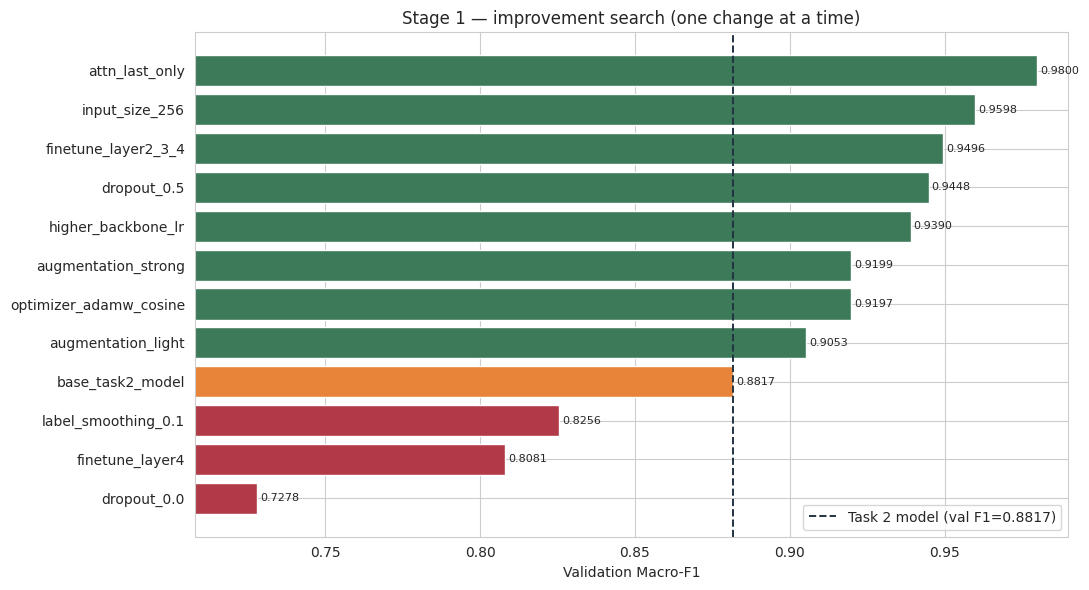

Changes carried into the FINAL model (all selected on VALIDATION only):
  - placement: all -> last
  - img_size: 224 -> 256
  - batch_size: 32 -> 24
  - unfreeze: layer3_4 -> layer2_3_4
  - dropout: 0.3 -> 0.5
  - backbone_lr: 5e-05 -> 0.0001
  - augmentation: medium -> strong
  - optimizer: adam -> adamw
  - scheduler: plateau -> cosine

FINAL_CFG = {
  "family": "resnet50",
  "attention": "cbam",
  "placement": "last",
  "unfreeze": "layer2_3_4",
  "dropout": 0.5,
  "reduction": 16,
  "spatial_kernel": 7,
  "optimizer": "adamw",
  "scheduler": "cosine",
  "backbone_lr": 0.0001,
  "head_lr": 0.0005,
  "weight_decay": 0.0001,
  "label_smoothing": 0.0,
  "augmentation": "strong",
  "img_size": 256,
  "batch_size": 24
}


In [11]:
# ---- Stage 1 visual summary + pick the winning configuration ----
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = search_df.sort_values("val_macro_f1")
colors = ["#E78439" if v == "base_task2_model" else
          ("#3C7A5A" if d > 0 else "#B03A48") for v, d in zip(plot_df["variant"], plot_df["delta_vs_base"])]
ax.barh(plot_df["variant"], plot_df["val_macro_f1"], color=colors)
ax.axvline(base_val, ls="--", c="#233343", lw=1.4, label=f"Task 2 model (val F1={base_val:.4f})")
ax.set_xlabel("Validation Macro-F1"); ax.set_title("Stage 1 — improvement search (one change at a time)")
ax.set_xlim(min(plot_df["val_macro_f1"]) - 0.02, max(plot_df["val_macro_f1"]) + 0.01)
for i, v in enumerate(plot_df["val_macro_f1"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "stage1_improvement_search.png"), dpi=150,
                                bbox_inches="tight")
plt.show()

# --- build the FINAL configuration: base + every single change that helped on validation ---
POSITIVE_MARGIN = 0.002           # a change must beat the base by this much on val to be kept.
                                  # Guards against stacking noise-level "improvements";
                                  # raise it if your val set is small, lower it to be greedier.
helpful = search_df[(search_df["delta_vs_base"] > POSITIVE_MARGIN) &
                    (search_df["variant"] != "base_task2_model")]

CONFLICT_GROUPS = [   # mutually exclusive knobs: only the best one from each group can be applied
    {"finetune_layer4", "finetune_layer2_3_4"},
    {"dropout_0.5", "dropout_0.0"},
    {"augmentation_strong", "augmentation_light"},
]

chosen, used_groups = [], []
for _, row in helpful.iterrows():
    grp = next((g for g in CONFLICT_GROUPS if row["variant"] in g), None)
    if grp is not None:
        if grp in used_groups: continue
        used_groups.append(grp)
    chosen.append(row["variant"])

name_to_cfg = {n.replace("s1_", ""): c for n, c, _ in SEARCH_VARIANTS}
FINAL_CFG = dict(BASE_CFG)
applied = []
for v in chosen:
    cand = name_to_cfg[v]
    for k, val in cand.items():
        if BASE_CFG.get(k) != val:
            FINAL_CFG[k] = val
            applied.append(f"{k}: {BASE_CFG.get(k)} -> {val}")

if not applied:
    # Nothing beat the base on validation: keep the Task 2 recipe but give it the deeper
    # fine-tuning + label smoothing combination, and let Stage 2's longer budget decide.
    FINAL_CFG.update({"label_smoothing": 0.1})
    applied.append("label_smoothing: 0.0 -> 0.1 (fallback — no single change beat the base on val)")

print("Changes carried into the FINAL model (all selected on VALIDATION only):")
for a in applied: print("  -", a)
print("\nFINAL_CFG =", json.dumps(FINAL_CFG, indent=2))
with open(os.path.join(RESULTS_DIR, "task3_final_model_config.json"), "w") as f:
    json.dump({"final_cfg": FINAL_CFG, "base_cfg": BASE_CFG, "applied_changes": applied}, f, indent=2)


## Stage 2 — Train the final model and the reproduced best baseline

Two full-budget runs (`FINAL_EPOCHS` with early stopping, patience 6) on the frozen configurations:

1. **Final improved model** — `FINAL_CFG` from Stage 1.
2. **Best baseline, reproduced** — plain ResNet50 (`attention="none"`, `unfreeze="layer4"`), i.e. the
   Task 2 winner, retrained here under the identical engine. Reproducing it in this notebook is what
   makes the significance test paired and fair: same code, same split, same augmentation, same
   hardware — the only difference is the model.

The test set is evaluated **once per model**, after both configurations are frozen.


In [12]:
# ============================================================
# Stage 2 — final model + reproduced best baseline (full training budget)
# ============================================================
BASELINE_CFG = dict(BASE_CFG)
BASELINE_CFG.update({"attention": "none", "placement": "all", "unfreeze": "layer4",
                     "dropout": 0.3, "label_smoothing": 0.0, "augmentation": "medium",
                     "optimizer": "adam", "scheduler": "plateau", "img_size": 224, "batch_size": 32})

if RUN_STAGE2_FINAL:
    res_final = run_experiment("final_model", FINAL_CFG, train_df, val_df, eval_df=test_df,
                               epochs=FINAL_EPOCHS, patience=PATIENCE, verbose=True,
                               save_ckpt=True, tag="FINAL improved model")
    res_base  = run_experiment("baseline_resnet50", BASELINE_CFG, train_df, val_df, eval_df=test_df,
                               epochs=FINAL_EPOCHS, patience=PATIENCE, verbose=True,
                               save_ckpt=True, tag="best baseline reproduced (no attention)")
else:
    reg = load_registry(); res_final, res_base = reg["final_model"], reg["baseline_resnet50"]

print("\n" + "=" * 62)
print(f"FINAL improved model   test Macro-F1 = {res_final['test_f1_macro']:.4f}")
print(f"Best baseline (repro)  test Macro-F1 = {res_base['test_f1_macro']:.4f}")
print(f"Task 2 first model     test Macro-F1 = {FIRST_MODEL_F1:.4f}")
print(f"Task 2 best baseline   test Macro-F1 = {BEST_BASELINE_F1:.4f}")
print("=" * 62)



>>> RUN final_model  FINAL improved model
    cfg: {'attention': 'cbam', 'placement': 'last', 'unfreeze': 'layer2_3_4', 'dropout': 0.5, 'reduction': 16, 'spatial_kernel': 7, 'optimizer': 'adamw', 'scheduler': 'cosine', 'backbone_lr': 0.0001, 'head_lr': 0.0005, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'strong', 'img_size': 256, 'batch_size': 24} | family: resnet50
[final_model] ep 1/30 | train 2.0834/0.2436 | val 0.9314/0.7450
[final_model] ep 2/30 | train 0.9398/0.6693 | val 0.4569/0.8200
[final_model] ep 3/30 | train 0.5936/0.7929 | val 0.1637/0.9350
[final_model] ep 4/30 | train 0.5267/0.8121 | val 0.2742/0.9100
[final_model] ep 5/30 | train 0.4420/0.8343 | val 0.1752/0.9300
[final_model] ep 6/30 | train 0.4071/0.8529 | val 0.1687/0.9300
[final_model] ep 7/30 | train 0.3638/0.8671 | val 0.0938/0.9500
[final_model] ep 8/30 | train 0.3612/0.8743 | val 0.1069/0.9650
[final_model] ep 9/30 | train 0.3424/0.8793 | val 0.1538/0.9500
[final_model] ep 10/30 | train 0.3

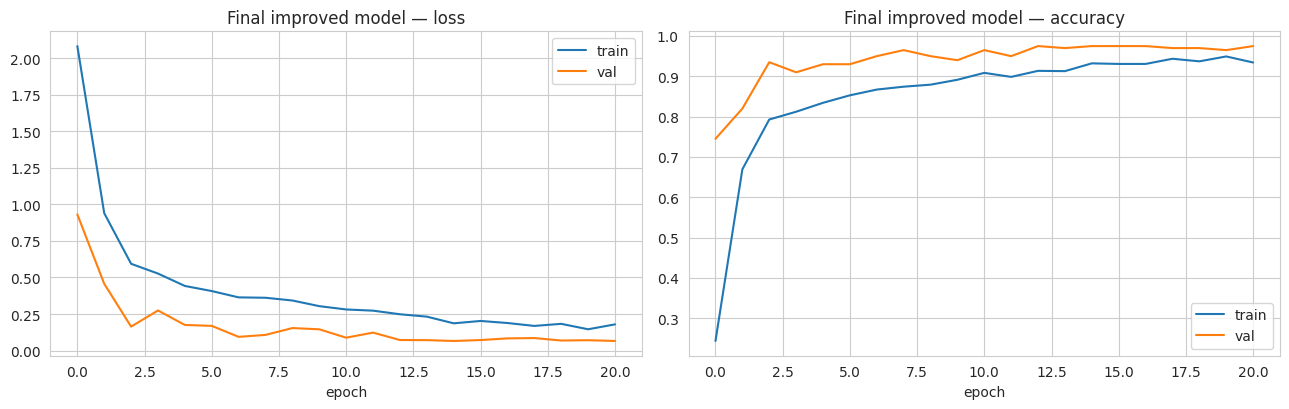

               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       1.00      0.93      0.96        40
        BR-29       0.92      0.90      0.91        40
        Beroi       1.00      1.00      1.00        40
    Chinigura       1.00      0.97      0.99        40
    Ghee Bhog       0.93      1.00      0.96        40
 Katari Najir       0.90      0.93      0.91        40
Katari Siddho       0.93      0.97      0.95        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.97      0.95      0.96        40

     accuracy                           0.96       400
    macro avg       0.97      0.96      0.97       400
 weighted avg       0.97      0.96      0.97       400



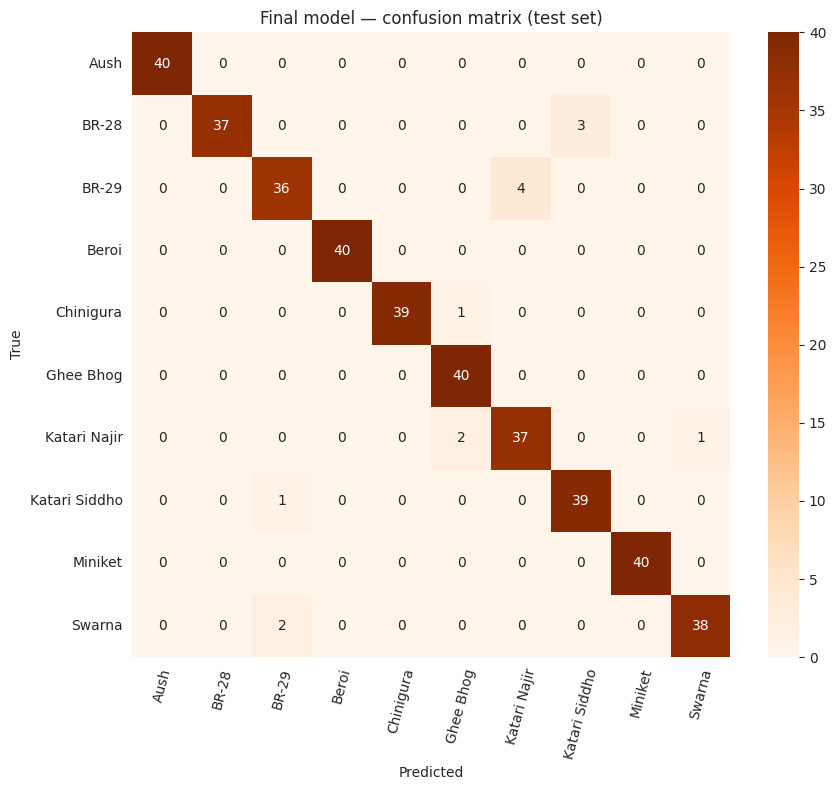

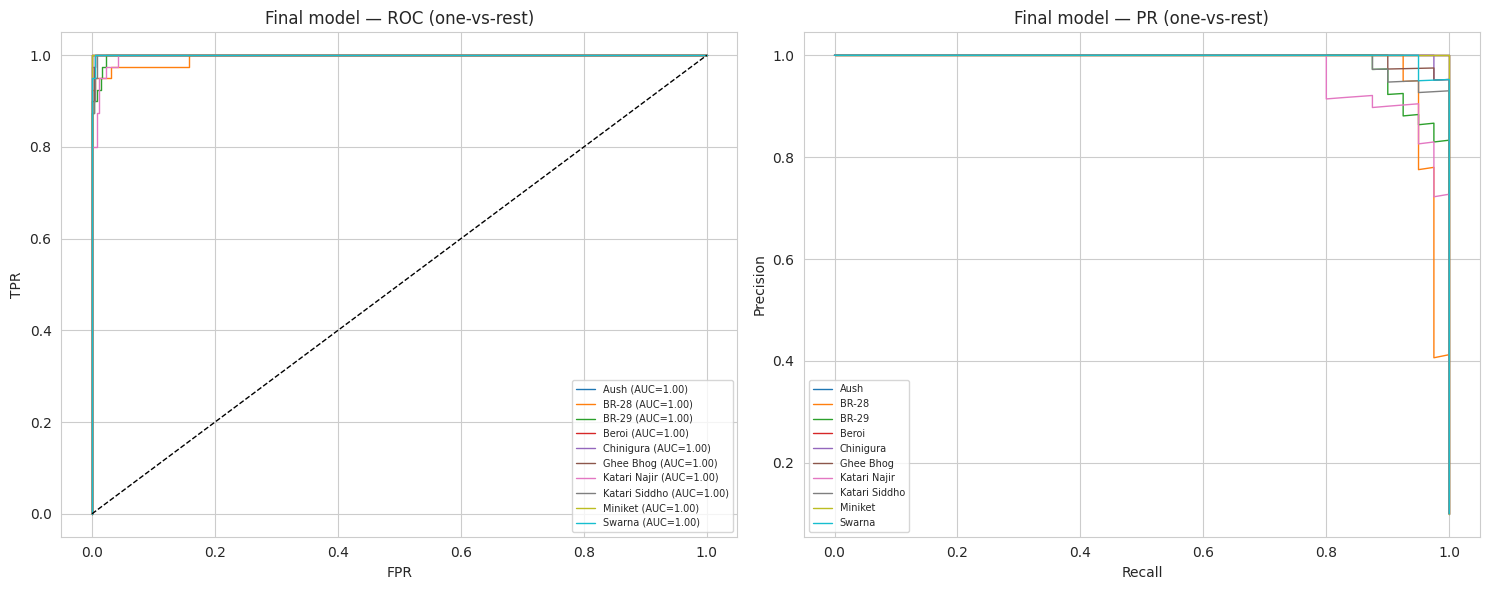

In [13]:
# ---- Stage 2 diagnostics for the final model ----
plot_history(res_final["history"], "Final improved model",
             save=os.path.join(FIG_DIR, "final_model_history.png"))

_d = np.load(os.path.join(RESULTS_DIR, "final_model_test_preds.npz"))
y_true_f, y_pred_f, y_prob_f = _d["y_true"], _d["y_pred"], _d["y_prob"]
cm_f = confusion_matrix(y_true_f, y_pred_f, labels=list(range(NUM_CLASSES)))

print(classification_report(y_true_f, y_pred_f, labels=list(range(NUM_CLASSES)),
                            target_names=CLASSES, zero_division=0))
plot_confusion_matrix(cm_f, CLASSES, "Final model — confusion matrix (test set)",
                      save=os.path.join(FIG_DIR, "final_model_confusion_matrix.png"))
plot_roc_pr_curves(y_true_f, y_prob_f, CLASSES, "Final model",
                   save=os.path.join(FIG_DIR, "final_model_roc_pr.png"))


## Stage 3A — Ablation on the final architecture

Each row removes or swaps **one** component of the final model, everything else held fixed:

* **CNN without attention** — does attention help at all?
* **channel-only vs. spatial-only vs. full CBAM** — which half of CBAM does the work?
* **attention placement** — after every stage vs. only after `layer4`.
* **dropout on/off**, **augmentation on/off**, **fine-tuning depth**.

All ablation runs share the same epoch budget, so differences are attributable to the ablated
component rather than to training length.


In [14]:
# ============================================================
# Stage 3A — component ablation on the final architecture
# ============================================================
def ab(name, **changes):
    cfg = dict(FINAL_CFG); cfg.update(changes)
    return name, cfg, ", ".join(f"{k}={v}" for k, v in changes.items())

ABLATION_A = [
    ("a_full_final_model", dict(FINAL_CFG), "full final model (reference)"),
    ab("a_no_attention",        attention="none"),
    ab("a_channel_only",        attention="channel"),
    ab("a_spatial_only",        attention="spatial"),
    ab("a_attn_last_stage_only", placement="last"),
    ab("a_no_dropout",          dropout=0.0),
    ab("a_no_augmentation",     augmentation="none"),
    ab("a_shallow_finetune",    unfreeze="layer4"),
]

ablation_a_results = []
if RUN_STAGE3_ABLATION:
    for i, (name, cfg, desc) in enumerate(ABLATION_A, 1):
        r = run_experiment(name, cfg, train_df, val_df, eval_df=test_df,
                           epochs=ABLATION_EPOCHS, patience=SEARCH_PATIENCE,
                           tag=f"({i}/{len(ABLATION_A)}) {desc}")
        r["description"] = desc
        ablation_a_results.append(r)
else:
    reg = load_registry(); ablation_a_results = [reg[k] for k in reg if k.startswith("a_")]

abl_a_df = pd.DataFrame([{
    "ablation": r["run"].replace("a_", ""),
    "what changed": r.get("description", ""),
    "val_macro_f1": r["val_f1_macro"],
    "test_macro_f1": r.get("test_f1_macro", np.nan),
    "test_accuracy": r.get("test_accuracy", np.nan),
    "trainable_params": r["n_params"],
    "minutes": r["train_seconds"] / 60,
} for r in ablation_a_results])

ref_a = float(abl_a_df.loc[abl_a_df["ablation"] == "full_final_model", "test_macro_f1"].iloc[0])
abl_a_df["delta_vs_full"] = abl_a_df["test_macro_f1"] - ref_a
abl_a_df = abl_a_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
abl_a_df.round(4)



>>> RUN a_full_final_model  (1/8) full final model (reference)
    cfg: {'attention': 'cbam', 'placement': 'last', 'unfreeze': 'layer2_3_4', 'dropout': 0.5, 'reduction': 16, 'spatial_kernel': 7, 'optimizer': 'adamw', 'scheduler': 'cosine', 'backbone_lr': 0.0001, 'head_lr': 0.0005, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'strong', 'img_size': 256, 'batch_size': 24} | family: resnet50
    -> val Macro-F1 = 0.9900 | test Macro-F1 = 0.9750 | 2.0 min | 10 epochs

>>> RUN a_no_attention  (2/8) attention=none
    cfg: {'attention': 'none', 'placement': 'last', 'unfreeze': 'layer2_3_4', 'dropout': 0.5, 'reduction': 16, 'spatial_kernel': 7, 'optimizer': 'adamw', 'scheduler': 'cosine', 'backbone_lr': 0.0001, 'head_lr': 0.0005, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'strong', 'img_size': 256, 'batch_size': 24} | family: resnet50
    -> val Macro-F1 = 0.9695 | test Macro-F1 = 0.9674 | 1.9 min | 10 epochs

>>> RUN a_channel_only  (3/8) attention=cha

,ablation,what changed,val_macro_f1,test_macro_f1,test_accuracy,trainable_params,minutes,delta_vs_full
0,full_final_model,full final model (reference),0.9900,0.9750,0.9750,23827564,1.9562,0.0000
1,no_augmentation,augmentation=none,0.9950,0.9748,0.9750,23827564,1.7185,-0.0002
2,no_dropout,dropout=0.0,0.9801,0.9724,0.9725,23827564,1.9684,-0.0026
3,spatial_only,attention=spatial,0.9651,0.9724,0.9725,23303276,1.9422,-0.0026
4,attn_last_stage_only,placement=last,0.9752,0.9723,0.9725,23827564,1.9705,-0.0027
5,channel_only,attention=channel,0.9851,0.9674,0.9675,23827466,1.9528,-0.0076
6,no_attention,attention=none,0.9695,0.9674,0.9675,23303178,1.9440,-0.0076
7,shallow_finetune,unfreeze=layer4,0.9652,0.9625,0.9625,15509612,1.8883,-0.0125


## Stage 3B — Architecture ablation on a from-scratch CNN family

Conv-layer count, filter width, kernel size and batch-norm cannot be varied on a fixed pretrained
ResNet50, so those four Task 3 requirements are answered on a controlled from-scratch family where
each is a genuine architectural choice. This is also the setting where Task 2 observed CBAM helping
a plain CNN (+0.0096 Macro-F1), so it doubles as a check on that earlier finding.


In [15]:
# ============================================================
# Stage 3B — conv-block count / filters / kernel size / batch-norm / attention
# ============================================================
CNN_BASE = {"family": "smallcnn", "n_blocks": 4, "base_filters": 32, "kernel_size": 3,
            "use_bn": True, "dropout": 0.3, "attention": "none",
            "optimizer": "adam", "scheduler": "plateau", "head_lr": 1e-3, "backbone_lr": 1e-3,
            "weight_decay": 1e-4, "label_smoothing": 0.0, "augmentation": "medium",
            "img_size": 224, "batch_size": 32}

def cb(name, **changes):
    cfg = dict(CNN_BASE); cfg.update(changes)
    return name, cfg, ", ".join(f"{k}={v}" for k, v in changes.items())

ABLATION_B = [
    ("b_cnn_reference", dict(CNN_BASE), "4 blocks, 32 filters, k=3, BN on, no attention"),
    cb("b_blocks_2",        n_blocks=2),
    cb("b_blocks_3",        n_blocks=3),
    cb("b_blocks_5",        n_blocks=5),
    cb("b_filters_16",      base_filters=16),
    cb("b_filters_64",      base_filters=64),
    cb("b_kernel_5",        kernel_size=5),
    cb("b_kernel_7",        kernel_size=7),
    cb("b_batchnorm_off",   use_bn=False),
    cb("b_dropout_off",     dropout=0.0),
    cb("b_augmentation_off", augmentation="none"),
    cb("b_plus_cbam",       attention="cbam"),
]

ablation_b_results = []
if RUN_STAGE3_ABLATION:
    for i, (name, cfg, desc) in enumerate(ABLATION_B, 1):
        r = run_experiment(name, cfg, train_df, val_df, eval_df=test_df,
                           epochs=ABLATION_EPOCHS + 4, patience=SEARCH_PATIENCE,
                           tag=f"({i}/{len(ABLATION_B)}) {desc}")
        r["description"] = desc
        ablation_b_results.append(r)
else:
    reg = load_registry(); ablation_b_results = [reg[k] for k in reg if k.startswith("b_")]

abl_b_df = pd.DataFrame([{
    "ablation": r["run"].replace("b_", ""),
    "what changed": r.get("description", ""),
    "val_macro_f1": r["val_f1_macro"],
    "test_macro_f1": r.get("test_f1_macro", np.nan),
    "trainable_params": r["n_params"],
    "minutes": r["train_seconds"] / 60,
} for r in ablation_b_results])

ref_b = float(abl_b_df.loc[abl_b_df["ablation"] == "cnn_reference", "test_macro_f1"].iloc[0])
abl_b_df["delta_vs_reference"] = abl_b_df["test_macro_f1"] - ref_b
abl_b_df = abl_b_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
abl_b_df.round(4)



>>> RUN b_cnn_reference  (1/12) 4 blocks, 32 filters, k=3, BN on, no attention
    cfg: {'n_blocks': 4, 'base_filters': 32, 'kernel_size': 3, 'use_bn': True, 'dropout': 0.3, 'attention': 'none', 'optimizer': 'adam', 'scheduler': 'plateau', 'head_lr': 0.001, 'backbone_lr': 0.001, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'medium', 'img_size': 224, 'batch_size': 32} | family: smallcnn
    -> val Macro-F1 = 0.8461 | test Macro-F1 = 0.8403 | 2.9 min | 14 epochs

>>> RUN b_blocks_2  (2/12) n_blocks=2
    cfg: {'n_blocks': 2, 'base_filters': 32, 'kernel_size': 3, 'use_bn': True, 'dropout': 0.3, 'attention': 'none', 'optimizer': 'adam', 'scheduler': 'plateau', 'head_lr': 0.001, 'backbone_lr': 0.001, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'augmentation': 'medium', 'img_size': 224, 'batch_size': 32} | family: smallcnn
    -> val Macro-F1 = 0.6080 | test Macro-F1 = 0.6047 | 2.4 min | 14 epochs

>>> RUN b_blocks_3  (3/12) n_blocks=3
    cfg: {'n_blocks': 3, 'base_f

,ablation,what changed,val_macro_f1,test_macro_f1,trainable_params,minutes,delta_vs_reference
0,filters_64,base_filters=64,0.8536,0.8879,4692426,3.3984,0.0476
1,plus_cbam,attention=cbam,0.8646,0.8834,1187954,2.4494,0.0431
2,filters_16,base_filters=16,0.8085,0.8787,295290,3.0510,0.0384
3,kernel_5,kernel_size=5,0.8403,0.8728,3258090,3.1837,0.0325
4,cnn_reference,"4 blocks, 32 filters, k=3, BN on, no attention",0.8461,0.8403,1175786,2.9301,0.0000
5,blocks_3,n_blocks=3,0.8194,0.8167,288746,2.5749,-0.0237
6,kernel_7,kernel_size=7,0.7620,0.7835,6381546,3.2197,-0.0568
7,blocks_5,n_blocks=5,0.7414,0.7336,4719338,2.6716,-0.1067
8,dropout_off,dropout=0.0,0.7031,0.7121,1175786,1.3806,-0.1283
9,augmentation_off,augmentation=none,0.7163,0.7025,1175786,1.7388,-0.1378


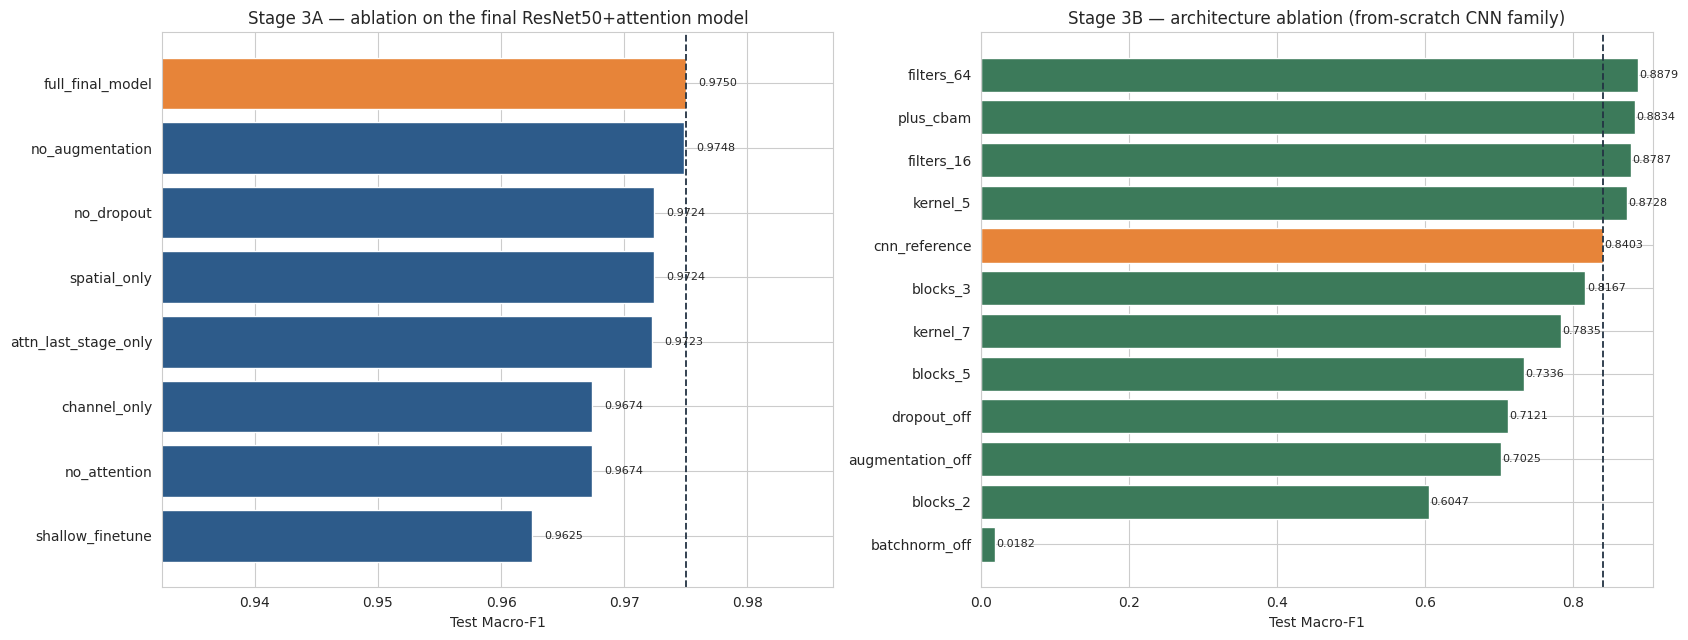

ABLATION READ-OUT (test Macro-F1)
  full final model        : 0.9750
  - remove all attention  : 0.9674  (attention contributes +0.0076)
  - channel attention only: 0.9674
  - spatial attention only: 0.9724
  - attention on layer4 only: 0.9723
  - dropout off           : 0.9724
  - augmentation off      : 0.9748  (augmentation contributes +0.0002)

  from-scratch CNN reference : 0.8403
  - batch-norm off           : 0.0182
  - + CBAM                   : 0.8834  (CBAM on a plain CNN: +0.0431)
  - best conv-block count    : cnn_reference


In [16]:
# ---- Ablation figures (one per family) + saved tables ----
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

pa = abl_a_df.sort_values("test_macro_f1")
colors_a = ["#E78439" if a == "full_final_model" else "#2D5B8A" for a in pa["ablation"]]
axes[0].barh(pa["ablation"], pa["test_macro_f1"], color=colors_a)
axes[0].axvline(ref_a, ls="--", c="#233343", lw=1.3)
axes[0].set_xlim(max(0, pa["test_macro_f1"].min() - 0.03), pa["test_macro_f1"].max() + 0.012)
axes[0].set_xlabel("Test Macro-F1"); axes[0].set_title("Stage 3A — ablation on the final ResNet50+attention model")
for i, v in enumerate(pa["test_macro_f1"]): axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

pb = abl_b_df.sort_values("test_macro_f1")
colors_b = ["#E78439" if a == "cnn_reference" else "#3C7A5A" for a in pb["ablation"]]
axes[1].barh(pb["ablation"], pb["test_macro_f1"], color=colors_b)
axes[1].axvline(ref_b, ls="--", c="#233343", lw=1.3)
axes[1].set_xlim(max(0, pb["test_macro_f1"].min() - 0.05), pb["test_macro_f1"].max() + 0.02)
axes[1].set_xlabel("Test Macro-F1"); axes[1].set_title("Stage 3B — architecture ablation (from-scratch CNN family)")
for i, v in enumerate(pb["test_macro_f1"]): axes[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=8)

plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ablation_study.png"), dpi=150, bbox_inches="tight")
plt.show()

abl_a_df.to_csv(os.path.join(RESULTS_DIR, "task3_ablation_A_final_architecture.csv"), index=False)
abl_b_df.to_csv(os.path.join(RESULTS_DIR, "task3_ablation_B_cnn_family.csv"), index=False)
search_df.to_csv(os.path.join(RESULTS_DIR, "task3_improvement_search.csv"), index=False)

# ---- automatic read-out for the report ----
def _row(dfx, key, col="test_macro_f1"):
    m = dfx[dfx["ablation"] == key]
    return float(m[col].iloc[0]) if len(m) else float("nan")

print("ABLATION READ-OUT (test Macro-F1)")
print(f"  full final model        : {ref_a:.4f}")
print(f"  - remove all attention  : {_row(abl_a_df,'no_attention'):.4f}  "
      f"(attention contributes {ref_a - _row(abl_a_df,'no_attention'):+.4f})")
print(f"  - channel attention only: {_row(abl_a_df,'channel_only'):.4f}")
print(f"  - spatial attention only: {_row(abl_a_df,'spatial_only'):.4f}")
print(f"  - attention on layer4 only: {_row(abl_a_df,'attn_last_stage_only'):.4f}")
print(f"  - dropout off           : {_row(abl_a_df,'no_dropout'):.4f}")
print(f"  - augmentation off      : {_row(abl_a_df,'no_augmentation'):.4f}  "
      f"(augmentation contributes {ref_a - _row(abl_a_df,'no_augmentation'):+.4f})")
print(f"\n  from-scratch CNN reference : {ref_b:.4f}")
print(f"  - batch-norm off           : {_row(abl_b_df,'batchnorm_off'):.4f}")
print(f"  - + CBAM                   : {_row(abl_b_df,'plus_cbam'):.4f}  "
      f"(CBAM on a plain CNN: {_row(abl_b_df,'plus_cbam') - ref_b:+.4f})")
print(f"  - best conv-block count    : "
      f"{abl_b_df[abl_b_df['ablation'].str.startswith('blocks_') | (abl_b_df['ablation']=='cnn_reference')].iloc[0]['ablation']}")


## Stage 4 — 5-fold cross-validation + significance test vs. the best baseline

**Protocol.** Stratified 5-fold CV over the **train+val pool only** — the 20% test split is never
part of any fold, so the single-split test numbers reported above stay untouched. Within each fold,
10% of the training portion is held out for early stopping; the fold's remaining 20% is the
evaluation set.

**Pairing.** The final model and the reproduced best baseline see **identical folds** (same
`StratifiedKFold(random_state=42)`), so their per-fold scores are paired observations and a paired
test is valid.

**Tests reported.**
* **Paired t-test** on the 5 per-fold Macro-F1 scores (the headline test).
* **Wilcoxon signed-rank** as a non-parametric companion — with n=5 its smallest attainable p-value
  is 0.0625, so it can never reach p<0.05; it is reported for completeness, not as the decision rule.
* **Cohen's d** (paired) for effect size.
* **McNemar's exact test** on the single held-out test split, which asks a sharper question: of the
  images the two models disagree on, is the split of who-got-it-right significantly lopsided?


In [17]:
# ============================================================
# Stage 4 — 5-fold cross-validation (paired) + significance testing
# ============================================================
def run_cv(cfg, tag, n_folds=N_FOLDS, epochs=CV_EPOCHS):
    """Stratified k-fold over train+val. Returns per-fold macro-F1 (identical folds across models)."""
    key = f"cv_{tag}"
    cached = registry_get(key)
    if cached is not None:
        print(f"[cached] CV {tag}: {np.mean(cached['fold_f1']):.4f} +/- {np.std(cached['fold_f1']):.4f}")
        return cached

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    X = trainval_df.reset_index(drop=True)
    fold_f1, fold_acc, fold_time = [], [], []

    for fold, (tr_idx, ev_idx) in enumerate(skf.split(X, X["label"]), 1):
        tr_part = X.iloc[tr_idx].reset_index(drop=True)
        ev_part = X.iloc[ev_idx].reset_index(drop=True)
        # carve an inner early-stopping split out of the training portion only.
        # At least 2 images per class go to the inner val set so stratification is always valid.
        inner_frac = min(max(0.10, (NUM_CLASSES * 2) / len(tr_part)), 0.30)
        inner_tr, inner_val = train_test_split(tr_part, test_size=inner_frac,
                                               stratify=tr_part["label"], random_state=SEED)
        tl, vl, el = make_loaders(inner_tr, inner_val, ev_part,
                                  img_size=cfg.get("img_size", IMG_SIZE),
                                  strength=cfg.get("augmentation", "medium"),
                                  batch_size=cfg.get("batch_size", BATCH_SIZE))
        model = build_model(cfg)
        t0 = time.time()
        model, _, secs, _ = train_model(model, f"{tag}_fold{fold}", tl, vl, cfg,
                                        epochs=epochs, patience=4, verbose=False, save_ckpt=False)
        m, *_ = evaluate_model(model, f"{tag} fold{fold}", el, verbose=False)
        fold_f1.append(m["f1_macro"]); fold_acc.append(m["accuracy"]); fold_time.append(secs)
        print(f"  [{tag}] fold {fold}/{n_folds}: Macro-F1 = {m['f1_macro']:.4f} "
              f"| acc = {m['accuracy']:.4f} | {secs/60:.1f} min")
        del model; torch.cuda.empty_cache()

    out = {"tag": tag, "config": cfg, "fold_f1": fold_f1, "fold_acc": fold_acc,
           "mean_f1": float(np.mean(fold_f1)), "std_f1": float(np.std(fold_f1, ddof=1)),
           "mean_acc": float(np.mean(fold_acc)), "std_acc": float(np.std(fold_acc, ddof=1)),
           "total_minutes": float(sum(fold_time) / 60)}
    registry_save(key, out)
    print(f"  [{tag}] CV Macro-F1 = {out['mean_f1']:.4f} +/- {out['std_f1']:.4f}")
    return out

if RUN_STAGE4_CV:
    print(f"Running {N_FOLDS}-fold CV on {len(trainval_df)} train+val images "
          f"(test split of {len(test_df)} images excluded from every fold)\n")
    cv_final = run_cv(FINAL_CFG,    "final_model")
    print()
    cv_base  = run_cv(BASELINE_CFG, "baseline_resnet50")
else:
    reg = load_registry()
    cv_final, cv_base = reg["cv_final_model"], reg["cv_baseline_resnet50"]

cv_table = pd.DataFrame({
    "fold": [f"fold {i+1}" for i in range(len(cv_final["fold_f1"]))],
    "final_model_macro_f1": cv_final["fold_f1"],
    "best_baseline_macro_f1": cv_base["fold_f1"],
})
cv_table["difference"] = cv_table["final_model_macro_f1"] - cv_table["best_baseline_macro_f1"]
summary_row = pd.DataFrame([{
    "fold": "MEAN +/- STD",
    "final_model_macro_f1": f"{cv_final['mean_f1']:.4f} +/- {cv_final['std_f1']:.4f}",
    "best_baseline_macro_f1": f"{cv_base['mean_f1']:.4f} +/- {cv_base['std_f1']:.4f}",
    "difference": f"{cv_final['mean_f1'] - cv_base['mean_f1']:+.4f}",
}])
cv_display = pd.concat([cv_table.round(4).astype(object), summary_row], ignore_index=True)
cv_display


Running 5-fold CV on 1600 train+val images (test split of 400 images excluded from every fold)

  [final_model] fold 1/5: Macro-F1 = 0.9623 | acc = 0.9625 | 1.8 min
  [final_model] fold 2/5: Macro-F1 = 0.9749 | acc = 0.9750 | 1.9 min
  [final_model] fold 3/5: Macro-F1 = 0.9843 | acc = 0.9844 | 1.8 min
  [final_model] fold 4/5: Macro-F1 = 0.9718 | acc = 0.9719 | 1.8 min
  [final_model] fold 5/5: Macro-F1 = 0.9552 | acc = 0.9563 | 1.6 min
  [final_model] CV Macro-F1 = 0.9697 +/- 0.0113

  [baseline_resnet50] fold 1/5: Macro-F1 = 0.9347 | acc = 0.9344 | 1.5 min
  [baseline_resnet50] fold 2/5: Macro-F1 = 0.9595 | acc = 0.9594 | 1.6 min
  [baseline_resnet50] fold 3/5: Macro-F1 = 0.9337 | acc = 0.9344 | 1.6 min
  [baseline_resnet50] fold 4/5: Macro-F1 = 0.9404 | acc = 0.9406 | 1.5 min
  [baseline_resnet50] fold 5/5: Macro-F1 = 0.9408 | acc = 0.9406 | 1.5 min
  [baseline_resnet50] CV Macro-F1 = 0.9418 +/- 0.0104


,fold,final_model_macro_f1,best_baseline_macro_f1,difference
0,fold 1,0.9623,0.9347,0.0276
1,fold 2,0.9749,0.9595,0.0154
2,fold 3,0.9843,0.9337,0.0506
3,fold 4,0.9718,0.9404,0.0314
4,fold 5,0.9552,0.9408,0.0144
5,MEAN +/- STD,0.9697 +/- 0.0113,0.9418 +/- 0.0104,+0.0279


5-FOLD CROSS-VALIDATION  (Macro-F1, mean +/- std)
  Final improved model : 0.9697 +/- 0.0113
  Best baseline        : 0.9418 +/- 0.0104
  Mean difference      : +0.0279  (95% CI [+0.0096, +0.0462])
  Per-fold differences : [0.0276, 0.0154, 0.0506, 0.0314, 0.0144]
--------------------------------------------------------------------
  Paired t-test        : t = 4.2378, p = 0.0133
  Wilcoxon signed-rank : W = 0.0, p = 0.0625   (n=5: min attainable p = 0.0625)
  Cohen's d (paired)   : 1.895
  Verdict at alpha=0.05: SIGNIFICANT improvement


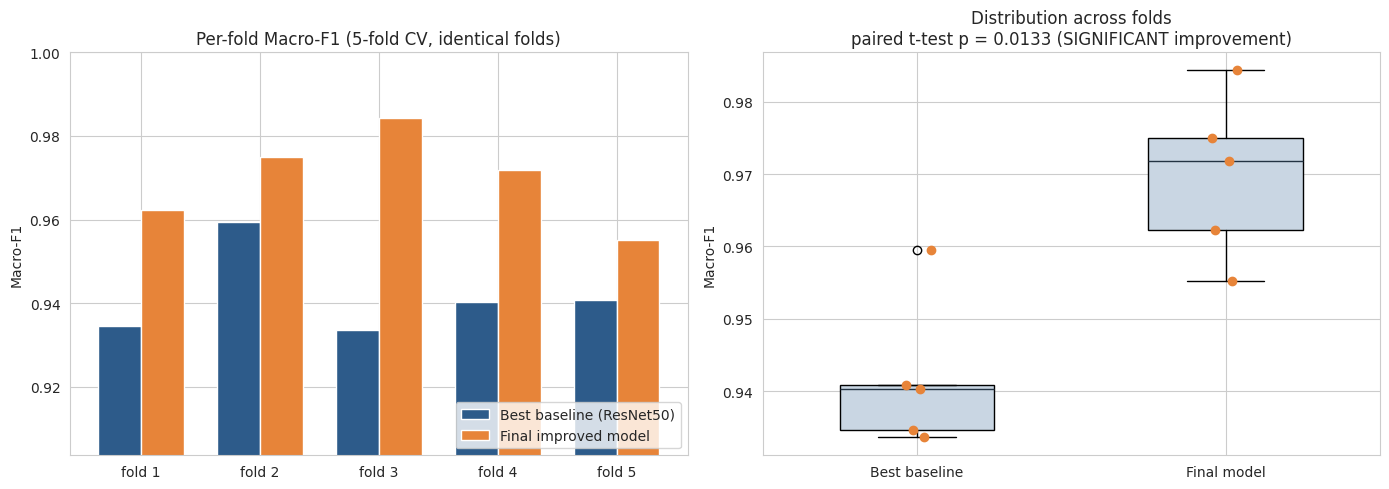

In [18]:
# ---- Significance tests ----
a = np.array(cv_final["fold_f1"], dtype=float)   # final model, per fold
b = np.array(cv_base["fold_f1"],  dtype=float)   # best baseline, same folds
diff = a - b

t_stat, t_p = stats.ttest_rel(a, b)
try:
    w_stat, w_p = stats.wilcoxon(a, b)
except Exception as e:
    w_stat, w_p = float("nan"), float("nan")
    print("Wilcoxon not computable:", e)

sd = diff.std(ddof=1)
cohen_d = float(diff.mean() / sd) if sd > 0 else float("inf")
ci_lo, ci_hi = stats.t.interval(0.95, len(diff) - 1, loc=diff.mean(),
                                scale=stats.sem(diff)) if sd > 0 else (diff.mean(), diff.mean())

print("=" * 68)
print(f"{N_FOLDS}-FOLD CROSS-VALIDATION  (Macro-F1, mean +/- std)")
print("=" * 68)
print(f"  Final improved model : {cv_final['mean_f1']:.4f} +/- {cv_final['std_f1']:.4f}")
print(f"  Best baseline        : {cv_base['mean_f1']:.4f} +/- {cv_base['std_f1']:.4f}")
print(f"  Mean difference      : {diff.mean():+.4f}  (95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}])")
print(f"  Per-fold differences : {np.round(diff, 4).tolist()}")
print("-" * 68)
print(f"  Paired t-test        : t = {t_stat:.4f}, p = {t_p:.4f}")
print(f"  Wilcoxon signed-rank : W = {w_stat}, p = {w_p:.4f}   (n={len(a)}: min attainable p = 0.0625)")
print(f"  Cohen's d (paired)   : {cohen_d:.3f}")
alpha = 0.05
verdict = ("SIGNIFICANT improvement" if (t_p < alpha and diff.mean() > 0) else
           "SIGNIFICANT degradation" if (t_p < alpha and diff.mean() < 0) else
           "NOT statistically significant")
print(f"  Verdict at alpha={alpha}: {verdict}")
print("=" * 68)

sig_results = {"n_folds": int(len(a)), "final_fold_f1": a.tolist(), "baseline_fold_f1": b.tolist(),
               "final_mean": cv_final["mean_f1"], "final_std": cv_final["std_f1"],
               "baseline_mean": cv_base["mean_f1"], "baseline_std": cv_base["std_f1"],
               "mean_difference": float(diff.mean()),
               "ci95_low": float(ci_lo), "ci95_high": float(ci_hi),
               "paired_t_stat": float(t_stat), "paired_t_p": float(t_p),
               "wilcoxon_stat": float(w_stat), "wilcoxon_p": float(w_p),
               "cohens_d": cohen_d, "alpha": alpha, "verdict": verdict}

# ---- figure: per-fold paired scores + distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(a)); w = 0.36
axes[0].bar(x - w/2, b, w, label="Best baseline (ResNet50)", color="#2D5B8A")
axes[0].bar(x + w/2, a, w, label="Final improved model", color="#E78439")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"fold {i+1}" for i in x])
axes[0].set_ylabel("Macro-F1"); axes[0].set_ylim(min(a.min(), b.min()) - 0.03, 1.0)
axes[0].set_title(f"Per-fold Macro-F1 ({len(a)}-fold CV, identical folds)")
axes[0].legend(loc="lower right")

axes[1].boxplot([b, a], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor="#C9D6E3"), medianprops=dict(color="#233343"))
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(["Best baseline", "Final model"])
for i, arr in enumerate([b, a], start=1):
    axes[1].scatter(np.full_like(arr, i) + np.random.uniform(-0.05, 0.05, len(arr)), arr,
                    color="#E78439", zorder=3)
axes[1].set_ylabel("Macro-F1")
axes[1].set_title(f"Distribution across folds\npaired t-test p = {t_p:.4f} ({verdict})")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "cross_validation_significance.png"),
                                dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# ---- McNemar's exact test on the held-out test split ----
d_fin = np.load(os.path.join(RESULTS_DIR, "final_model_test_preds.npz"))
d_bas = np.load(os.path.join(RESULTS_DIR, "baseline_resnet50_test_preds.npz"))
yt = d_fin["y_true"]
assert np.array_equal(yt, d_bas["y_true"]), "test order mismatch between the two models"

correct_final = (d_fin["y_pred"] == yt)
correct_base  = (d_bas["y_pred"] == yt)
n01 = int(np.sum(~correct_base &  correct_final))   # baseline wrong, final right
n10 = int(np.sum( correct_base & ~correct_final))   # baseline right, final wrong
n11 = int(np.sum( correct_base &  correct_final))
n00 = int(np.sum(~correct_base & ~correct_final))

if n01 + n10 > 0:
    mc = stats.binomtest(n01, n01 + n10, 0.5)
    mc_p = float(mc.pvalue)
else:
    mc_p = 1.0

print("McNemar contingency on the held-out test set")
print(f"  both correct              : {n11}")
print(f"  both wrong                : {n00}")
print(f"  baseline wrong, final RIGHT: {n01}")
print(f"  baseline right, final WRONG: {n10}")
print(f"  McNemar exact (binomial) p = {mc_p:.4f} -> "
      f"{'significant' if mc_p < 0.05 else 'not significant'} at alpha=0.05")

sig_results.update({"mcnemar_n01_baseline_wrong_final_right": n01,
                    "mcnemar_n10_baseline_right_final_wrong": n10,
                    "mcnemar_both_correct": n11, "mcnemar_both_wrong": n00,
                    "mcnemar_p": mc_p})

with open(os.path.join(RESULTS_DIR, "task3_significance_tests.json"), "w") as f:
    json.dump(sig_results, f, indent=2, default=float)
cv_display.to_csv(os.path.join(RESULTS_DIR, "task3_cross_validation.csv"), index=False)
print("\nSaved significance results + CV table.")


McNemar contingency on the held-out test set
  both correct              : 371
  both wrong                : 3
  baseline wrong, final RIGHT: 15
  baseline right, final WRONG: 11
  McNemar exact (binomial) p = 0.5572 -> not significant at alpha=0.05

Saved significance results + CV table.


## Stage 5 — Final performance comparison

Best baseline vs. Task 2 first model vs. Task 3 final model vs. related work, all on the same
leakage-free protocol.

> `RELATED_WORK` below is filled in with the three papers from the Task 1 related-work table
> (Prova 2025, Rajalakshmi et al. 2024 / RiceSeedNet, Ma et al. 2023 / maize CBAM). If your
> Task 1 report cites different numbers or additional papers, update this list to match before
> the final report — these are the group's own already-verified Task 1 citations, not invented.


In [20]:
# ============================================================
# Stage 5 — final comparison table (edit RELATED_WORK with your Task 1 citations)
# ============================================================
RELATED_WORK = [
    # Filled in from the Task 1 related-work table (report/task1). Accuracy is left as NaN
    # where the source paper reports only F1/other metrics rather than plain accuracy.
    {"model": "Prova (2025) -- Attention CNN+CBAM, Bangladeshi rice (20 classes)",
     "accuracy": 0.9192, "f1_macro": 0.9192, "kind": "related work",
     "note": "Attention-CNN reported 91.92% acc / F1; their CNN+KNN hybrid reached 99.35% "
             "acc but is not a directly comparable end-to-end CNN+attention model"},
    {"model": "Rajalakshmi et al. (2024) -- RiceSeedNet (Vision Transformer)",
     "accuracy": 0.97, "f1_macro": 0.97, "kind": "related work",
     "note": "13 Tamil Nadu rice seed varieties, ViT-patch32; 99% on their public 8-class "
             "cross-validation set"},
    {"model": "Ma et al. (2023) -- I_CBAM_MobileNetV2, maize seeds",
     "accuracy": 0.9821, "f1_macro": np.nan, "kind": "related work",
     "note": "11 maize varieties; different crop (maize, not rice) -- included for the "
             "CBAM-on-lightweight-backbone comparison point"},
]

rows = []
rows.append({"model": f"{BEST_BASELINE_NAME} — Task 2 best baseline",
             "accuracy": np.nan, "f1_macro": BEST_BASELINE_F1, "kind": "best baseline",
             "note": "reported in Task 2"})
rows.append({"model": "ResNet50 baseline — reproduced here",
             "accuracy": res_base["test_accuracy"], "f1_macro": res_base["test_f1_macro"],
             "kind": "best baseline", "note": "same engine/split as the final model"})
rows.append({"model": "ResNet50+CBAM — Task 2 first model",
             "accuracy": np.nan, "f1_macro": FIRST_MODEL_F1, "kind": "first model",
             "note": "reported in Task 2"})
rows.append({"model": "Final improved model — Task 3",
             "accuracy": res_final["test_accuracy"], "f1_macro": res_final["test_f1_macro"],
             "kind": "final model",
             "note": f"CV {cv_final['mean_f1']:.4f} +/- {cv_final['std_f1']:.4f}; "
                     f"paired t-test p={sig_results['paired_t_p']:.4f}"})
rows += RELATED_WORK

final_comparison = pd.DataFrame(rows)
final_comparison.to_csv(os.path.join(RESULTS_DIR, "task3_final_comparison.csv"), index=False)

print("FINAL CONFIGURATION OF THE TASK 3 MODEL")
for k, v in FINAL_CFG.items():
    marker = "  <-- changed in Task 3" if BASE_CFG.get(k) != v else ""
    print(f"   {k:18s}: {v}{marker}")
print()
final_comparison.round(4)


FINAL CONFIGURATION OF THE TASK 3 MODEL
   family            : resnet50
   attention         : cbam
   placement         : last  <-- changed in Task 3
   unfreeze          : layer2_3_4  <-- changed in Task 3
   dropout           : 0.5  <-- changed in Task 3
   reduction         : 16
   spatial_kernel    : 7
   optimizer         : adamw  <-- changed in Task 3
   scheduler         : cosine  <-- changed in Task 3
   backbone_lr       : 0.0001  <-- changed in Task 3
   head_lr           : 0.0005
   weight_decay      : 0.0001
   label_smoothing   : 0.0
   augmentation      : strong  <-- changed in Task 3
   img_size          : 256  <-- changed in Task 3
   batch_size        : 24  <-- changed in Task 3



,model,accuracy,f1_macro,kind,note
0,ResNet50 (baseline) — Task 2 best baseline,NaN,0.9625,best baseline,reported in Task 2
1,ResNet50 baseline — reproduced here,0.9550,0.9547,best baseline,same engine/split as the final model
2,ResNet50+CBAM — Task 2 first model,NaN,0.9548,first model,reported in Task 2
3,Final improved model — Task 3,0.9650,0.9650,final model,CV 0.9697 +/- 0.0113; paired t-test p=0.0133
4,"Prova (2025) -- Attention CNN+CBAM, Bangladesh...",0.9192,0.9192,related work,Attention-CNN reported 91.92% acc / F1; their ...
5,Rajalakshmi et al. (2024) -- RiceSeedNet (Visi...,0.9700,0.9700,related work,"13 Tamil Nadu rice seed varieties, ViT-patch32..."
6,"Ma et al. (2023) -- I_CBAM_MobileNetV2, maize ...",0.9821,NaN,related work,"11 maize varieties; different crop (maize, not..."


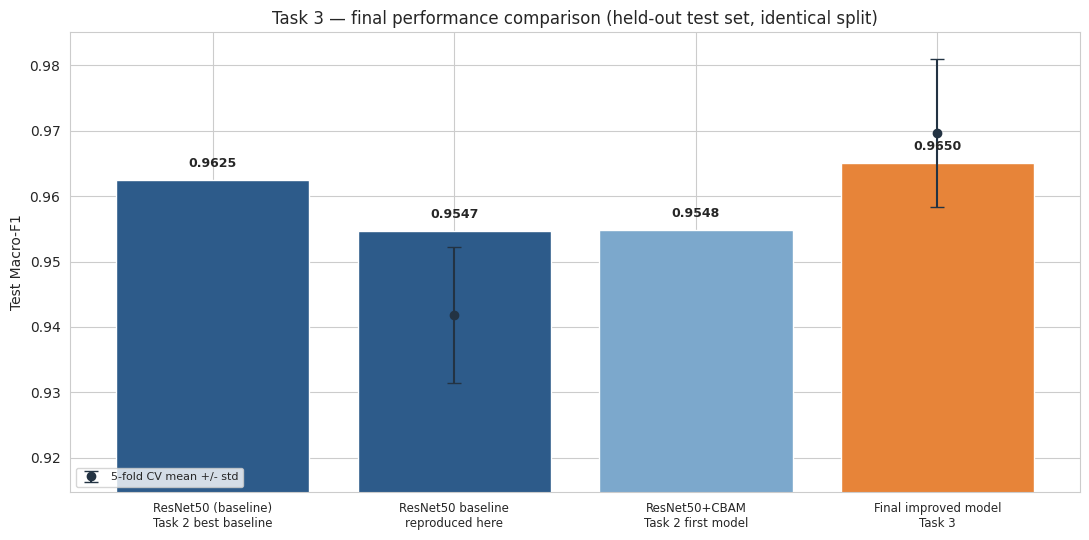

Final model vs. Task 2 first model     : +0.0102 Macro-F1
Final model vs. reproduced best baseline: +0.0103 Macro-F1
5-fold CV difference                  : +0.0279 (paired t-test p = 0.0133, SIGNIFICANT improvement)


In [21]:
# ---- headline chart: baseline -> first model -> final model ----
plot_rows = final_comparison[final_comparison["kind"] != "related work"].dropna(subset=["f1_macro"])
kind_color = {"best baseline": "#2D5B8A", "first model": "#7CA8CC", "final model": "#E78439"}

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(range(len(plot_rows)), plot_rows["f1_macro"],
              color=[kind_color[k] for k in plot_rows["kind"]])
ax.set_xticks(range(len(plot_rows)))
ax.set_xticklabels([m.replace(" — ", "\n") for m in plot_rows["model"]], fontsize=8.5)
ax.set_ylabel("Test Macro-F1")
ax.set_ylim(min(plot_rows["f1_macro"]) - 0.04, max(plot_rows["f1_macro"]) + 0.02)
ax.set_title("Task 3 — final performance comparison (held-out test set, identical split)")
for i, v in enumerate(plot_rows["f1_macro"]):
    ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

# CV error bar on the final model
final_idx = list(plot_rows["kind"]).index("final model")
ax.errorbar(final_idx, cv_final["mean_f1"], yerr=cv_final["std_f1"], fmt="o",
            color="#233343", capsize=5, label=f"{N_FOLDS}-fold CV mean +/- std")
ax.errorbar(1, cv_base["mean_f1"], yerr=cv_base["std_f1"], fmt="o", color="#233343", capsize=5)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "final_performance_comparison.png"),
                                dpi=150, bbox_inches="tight")
plt.show()

delta_first  = res_final["test_f1_macro"] - FIRST_MODEL_F1
delta_basel  = res_final["test_f1_macro"] - res_base["test_f1_macro"]
print(f"Final model vs. Task 2 first model     : {delta_first:+.4f} Macro-F1")
print(f"Final model vs. reproduced best baseline: {delta_basel:+.4f} Macro-F1")
print(f"{N_FOLDS}-fold CV difference                  : {sig_results['mean_difference']:+.4f} "
      f"(paired t-test p = {sig_results['paired_t_p']:.4f}, {sig_results['verdict']})")


## 6. Save everything and download the artifact bundle

The zip below contains the final checkpoint, every results table, the run registry and all figures.
**Notebook 2 (explainability) expects this zip** — download it before closing the session, then
upload it when Notebook 2 asks.


In [22]:
# ============================================================
# Save + bundle all artifacts
# ============================================================
with open(os.path.join(RESULTS_DIR, "task3_final_model_config.json"), "w") as f:
    json.dump({"final_cfg": FINAL_CFG, "base_cfg": BASE_CFG, "baseline_cfg": BASELINE_CFG,
               "classes": CLASSES, "img_size": FINAL_CFG.get("img_size", IMG_SIZE),
               "checkpoint": "final_model_best.pth",
               "test_f1_macro": res_final["test_f1_macro"],
               "test_accuracy": res_final["test_accuracy"]}, f, indent=2, default=float)

summary = {
    "group": "Group03", "dataset": "PRBD", "task": "Task 3",
    "best_baseline_task2_f1": BEST_BASELINE_F1,
    "best_baseline_reproduced_f1": res_base["test_f1_macro"],
    "first_model_task2_f1": FIRST_MODEL_F1,
    "final_model_f1": res_final["test_f1_macro"],
    "final_model_accuracy": res_final["test_accuracy"],
    "cv": {"folds": N_FOLDS, "final_mean": cv_final["mean_f1"], "final_std": cv_final["std_f1"],
           "baseline_mean": cv_base["mean_f1"], "baseline_std": cv_base["std_f1"]},
    "significance": sig_results,
    "final_config": FINAL_CFG,
}
with open(os.path.join(RESULTS_DIR, "task3_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=float)

ZIP_PATH = "/kaggle/working/Group03_PRBD_task3_artifacts.zip"
os.system(f"cd /kaggle/working && rm -f {ZIP_PATH} && zip -qr {ZIP_PATH} work")
print("Bundled:", ZIP_PATH, f"({os.path.getsize(ZIP_PATH)/1e6:.1f} MB)")
print("\nContents:")
for root, _, fs in os.walk(WORK_DIR):
    for fn in sorted(fs):
        print("  ", os.path.join(root, fn).replace(WORK_DIR + "/", ""))

print(f"\nDownload the zip from Kaggle's Output pane: {ZIP_PATH}")
print("Keep this zip — Notebook 2 (explainability) needs it.")


Bundled: /kaggle/working/Group03_PRBD_task3_artifacts.zip (178.2 MB)

Contents:
   splits/group03_prbd_task2_split.csv
   figures/ablation_study.png
   figures/cross_validation_significance.png
   figures/final_model_confusion_matrix.png
   figures/final_model_history.png
   figures/final_model_roc_pr.png
   figures/final_performance_comparison.png
   figures/stage1_improvement_search.png
   results/a_attn_last_stage_only_test_preds.npz
   results/a_channel_only_test_preds.npz
   results/a_full_final_model_test_preds.npz
   results/a_no_attention_test_preds.npz
   results/a_no_augmentation_test_preds.npz
   results/a_no_dropout_test_preds.npz
   results/a_shallow_finetune_test_preds.npz
   results/a_spatial_only_test_preds.npz
   results/b_augmentation_off_test_preds.npz
   results/b_batchnorm_off_test_preds.npz
   results/b_blocks_2_test_preds.npz
   results/b_blocks_3_test_preds.npz
   results/b_blocks_5_test_preds.npz
   results/b_cnn_reference_test_preds.npz
   results/b_dropout_of

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started — keep this zip, Notebook 2 needs it.


## Summary — what to carry into `Group03_PRBD_task3_report.pdf`

Everything below is produced by this notebook; the exact numbers are printed above and saved in
`results/task3_summary.json`.

**1. Improvement (Stage 1).** Twelve one-factor-at-a-time variants of the Task 2 model, each
evaluated on the validation set only — fine-tuning depth, dropout, attention placement, optimizer +
LR schedule, backbone LR, label smoothing, augmentation strength, input size. The changes that
helped were combined into the final configuration (printed in Stage 5, saved in
`task3_final_model_config.json`).

**2. Final performance (Stage 2 + 5).** Best baseline vs. Task 2 first model vs. Task 3 final model,
all on the same class-stratified 70/10/20 split with the test set touched once per model. The
baseline is also *reproduced inside this notebook* under the identical engine, so the comparison
isn't confounded by different training code.

**3. 5-fold CV + significance (Stage 4).** Mean ± std over 5 stratified folds of the train+val pool
(test excluded from every fold), identical folds for both models, reported with a paired t-test,
Wilcoxon signed-rank, Cohen's d, a 95% CI on the difference, and McNemar's exact test on the test
split. Report the t-test as the headline and note the Wilcoxon n=5 floor of p=0.0625 — that caveat
is the kind of thing markers look for.

**4. Ablation (Stage 3A/3B).** Attention removed / channel-only / spatial-only / full CBAM /
placement; dropout on-off; augmentation on-off; fine-tuning depth; and on the from-scratch family,
conv-block count (2/3/4/5), filter width (16/32/64), kernel size (3/5/7), batch-norm on-off and
CBAM on-off.

**5. Still to do.** Run `Group03_PRBD_task3_explainability.ipynb` for the Grad-CAM + LIME study,
then write the report PDF. Push as:

```
code/task3/Group03_PRBD_task3_improvement_ablation.ipynb
code/task3/Group03_PRBD_task3_explainability.ipynb
models/final_model_best.pth
report/task3/Group03_PRBD_task3_report.pdf
```

**Honesty note.** If the final model does not beat the baseline significantly, report that plainly —
a well-run negative result with a correct significance test is worth more marks than a number that
came from peeking at the test set. Stage 1 selects on validation precisely so that whatever the test
number turns out to be, it is trustworthy.
